In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [98]:
results_path = "../results"
ppm_res = pd.read_csv(f"{results_path}/planner_comp_results_all_detailed.csv")
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 20, 'axes.labelsize': 20, 'axes.titlesize': 20})

indices = ppm_res[ppm_res['heuristic'] == 'MIXED_G'].index
ppm_res.loc[indices, 'heuristic'] = 'MULTI_BOUND'
ppm_res_mean_cost = ppm_res.groupby(['heuristic', 'num_objects'])['cost'].mean().reset_index()
ppm_res_mean_time = ppm_res.groupby(['heuristic', 'num_objects'])['time_taken'].mean().reset_index()
ppm_res_mean_states = ppm_res.groupby(['heuristic', 'num_objects'])['states_explored'].mean().reset_index()

ppm_res_mean_cost_to_100 = ppm_res_mean_cost[ppm_res_mean_cost['num_objects'] <= 100]
ppm_res_mean_cost_from_100 = ppm_res_mean_cost[ppm_res_mean_cost['num_objects'] >= 100]

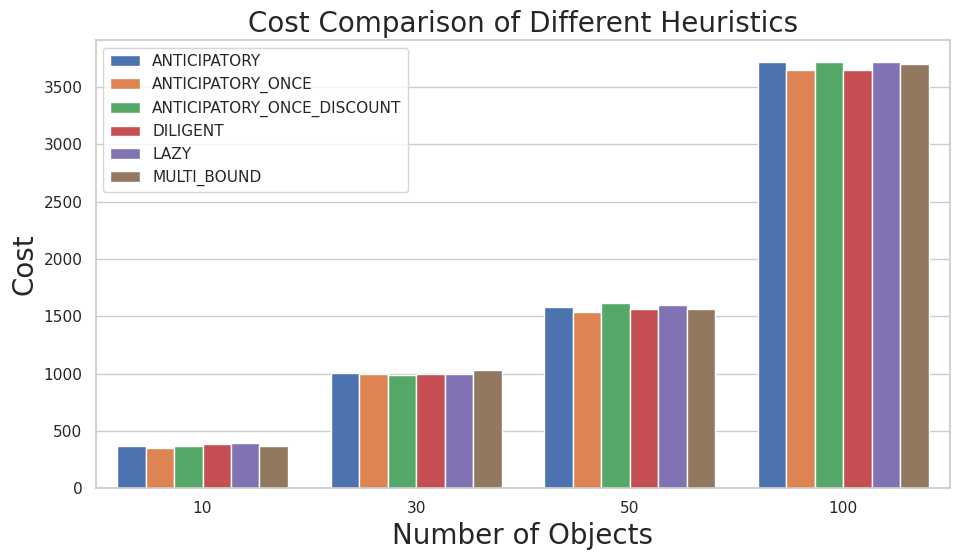

In [99]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(data=ppm_res_mean_cost_to_100, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Cost Comparison of Different Heuristics")
plt.legend()
plt.tight_layout()
plt.show()

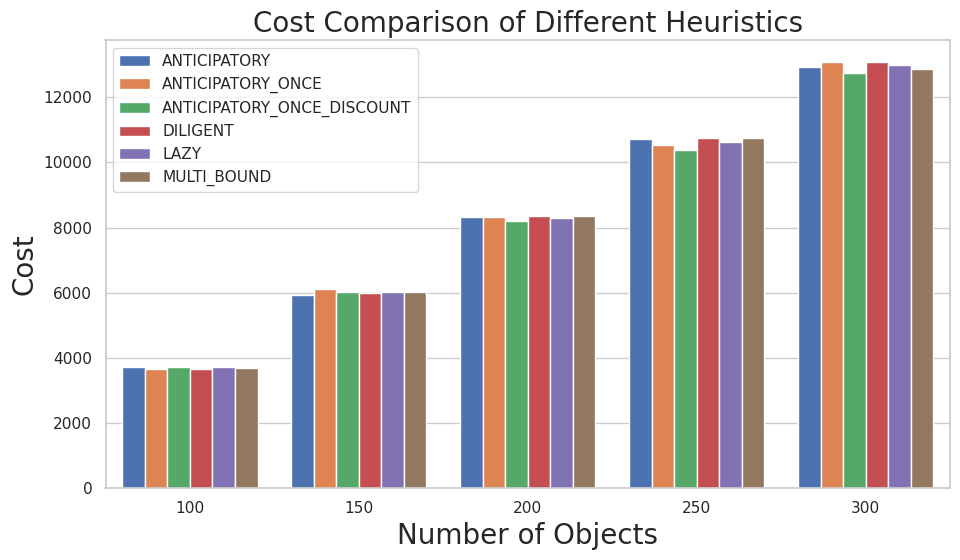

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(data=ppm_res_mean_cost_from_100, x="num_objects", y="cost", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Cost Comparison of Different Heuristics")
plt.legend()
plt.tight_layout()
plt.show()

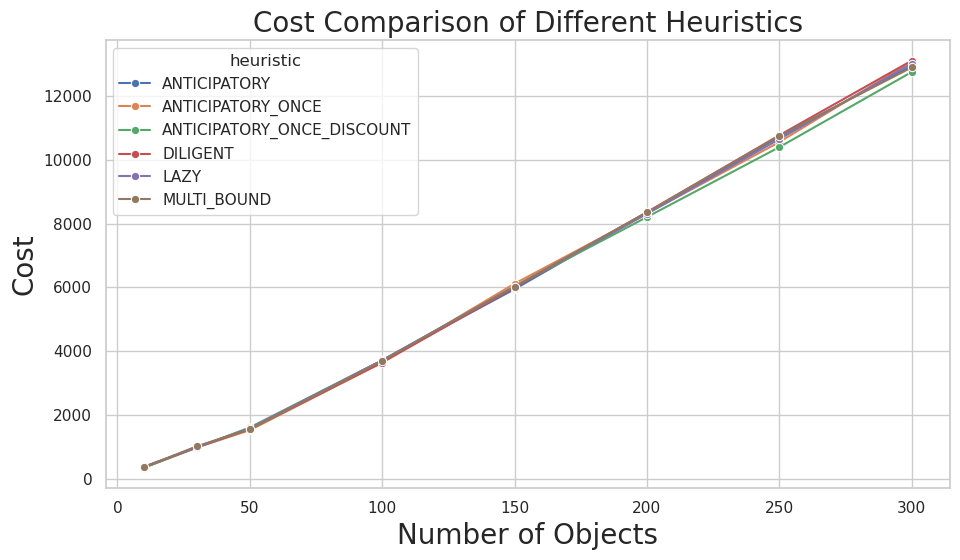

In [80]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.lineplot(data=ppm_res_mean_cost, x="num_objects", y="cost", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Cost Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

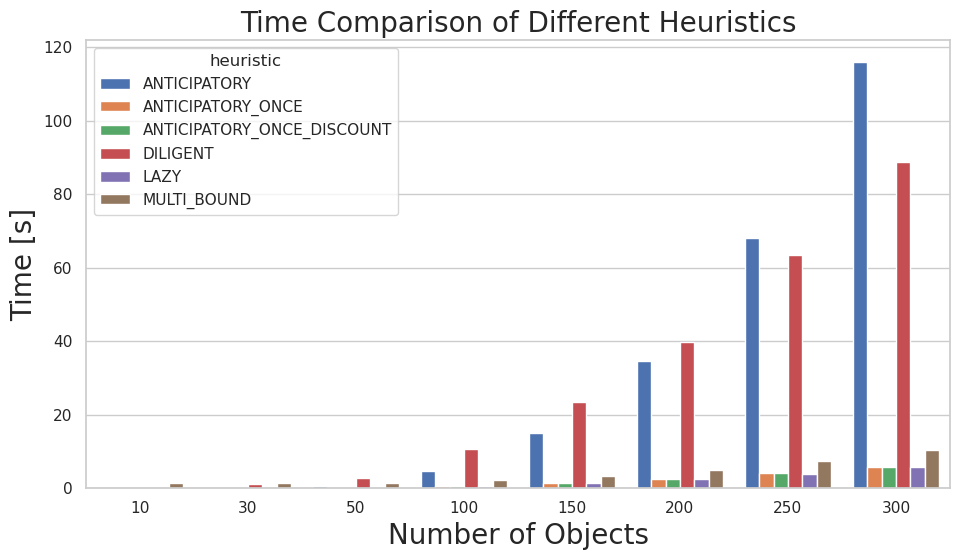

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(data=ppm_res_mean_time, x="num_objects", y="time_taken", hue="heuristic", ax=ax, saturation=1.0)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time [s]")
ax.set_title("Time Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

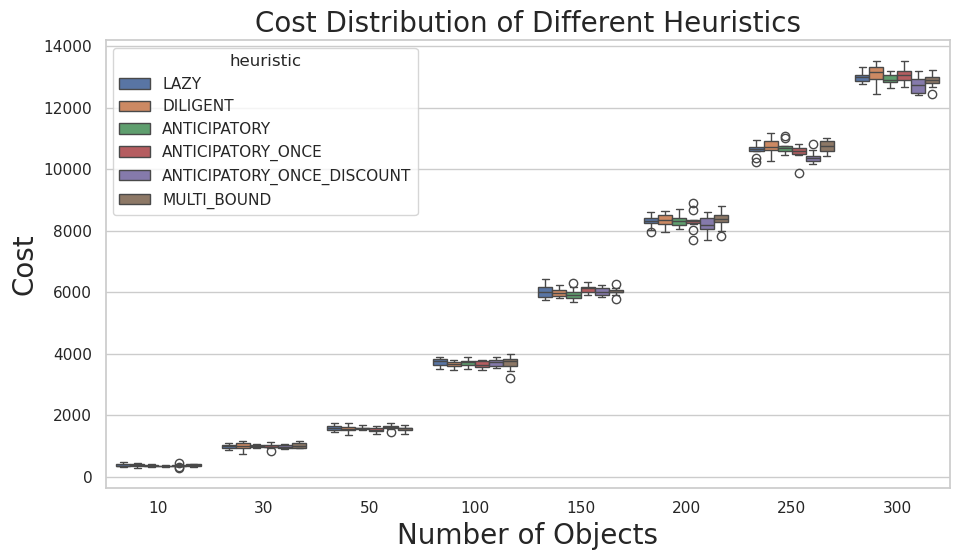

In [86]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.boxplot(data=ppm_res, x="num_objects", y="cost", hue="heuristic", ax=ax)
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Cost")
ax.set_title("Cost Distribution of Different Heuristics")
plt.tight_layout()
plt.show()

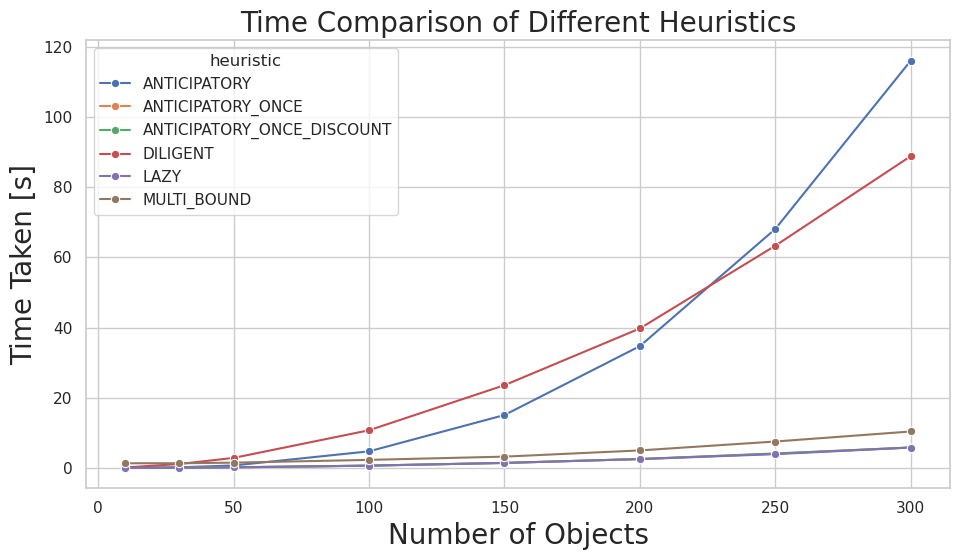

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.lineplot(data=ppm_res_mean_time, x="num_objects", y="time_taken", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Time Taken [s]")
ax.set_title("Time Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

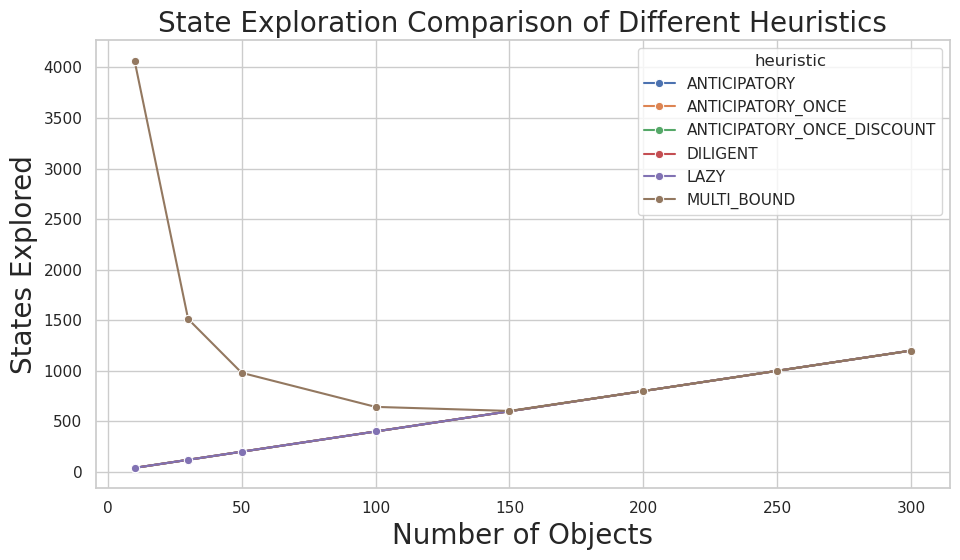

In [90]:
fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.lineplot(data=ppm_res_mean_states, x="num_objects", y="states_explored", hue="heuristic", ax=ax, marker='o')
ax.set_xlabel("Number of Objects")
ax.set_ylabel("States Explored")
ax.set_title("State Exploration Comparison of Different Heuristics")
plt.tight_layout()
plt.show()

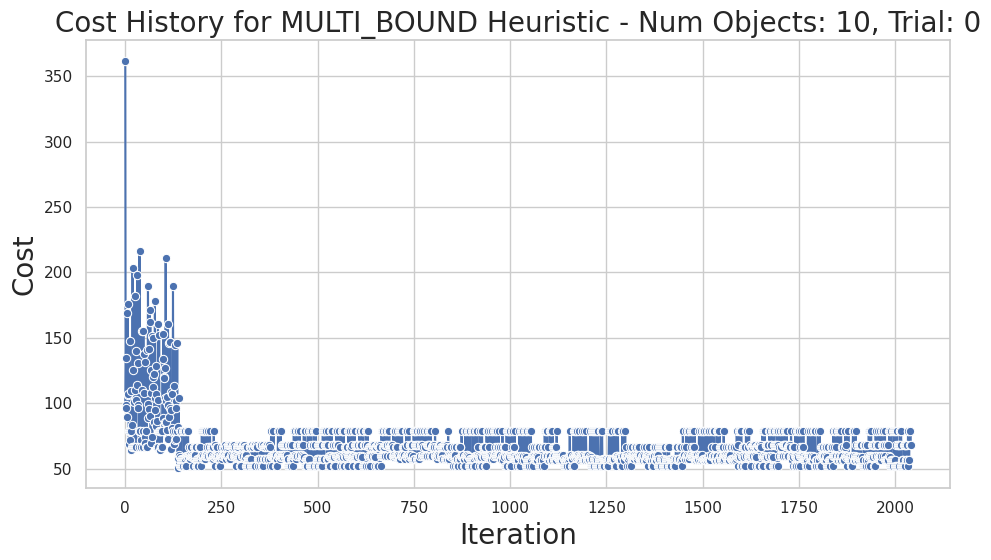

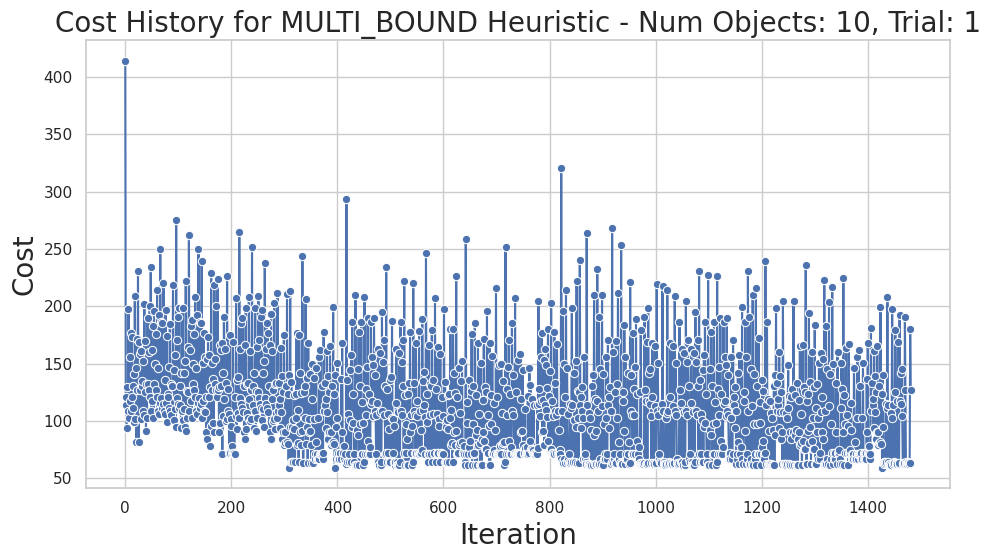

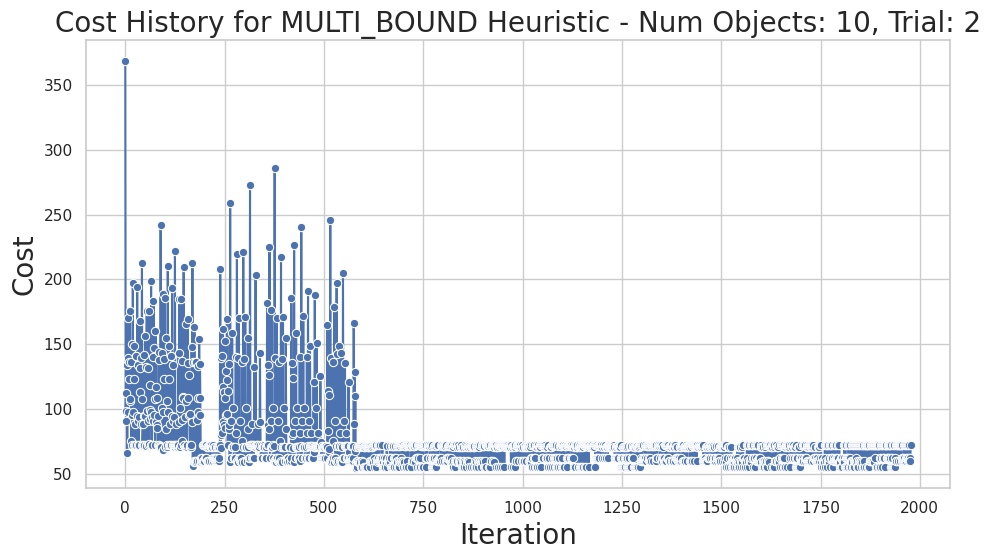

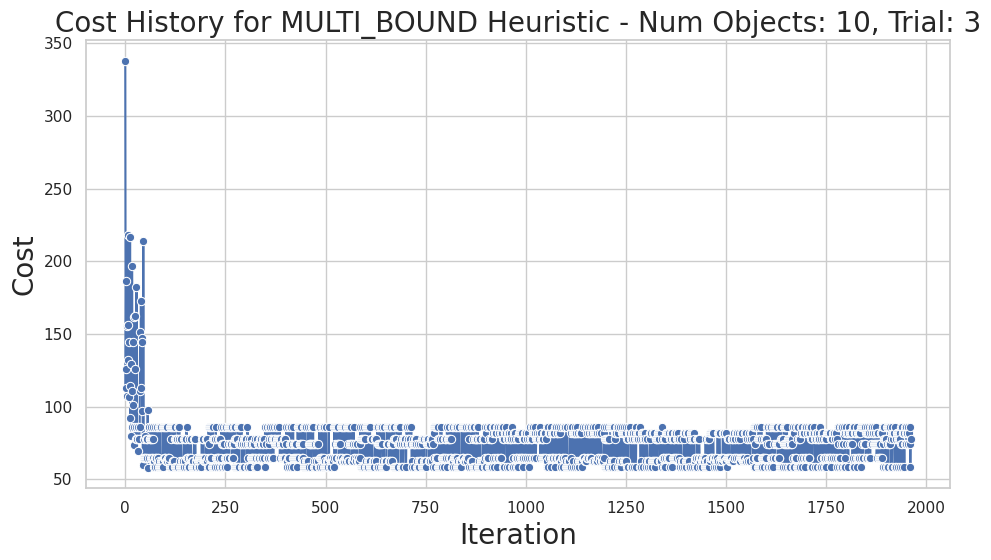

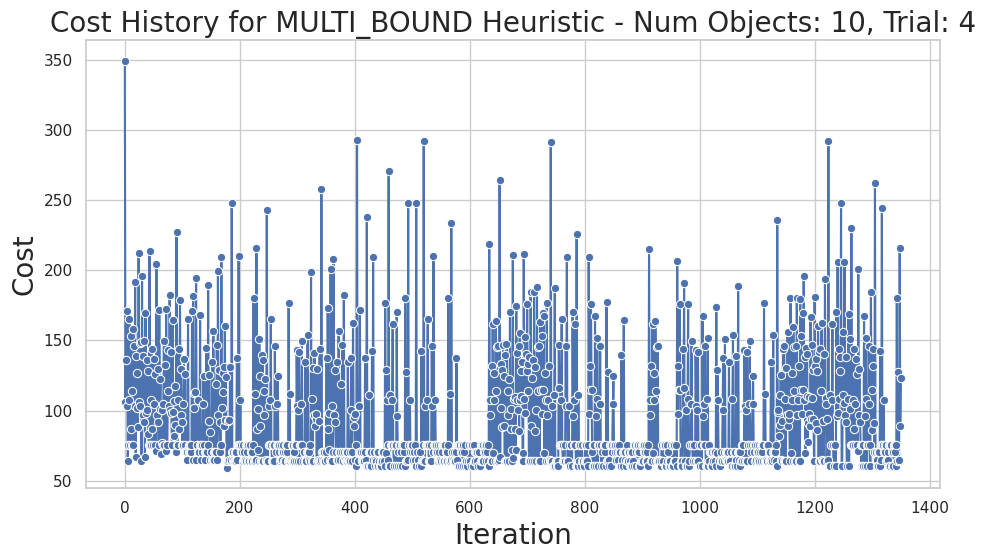

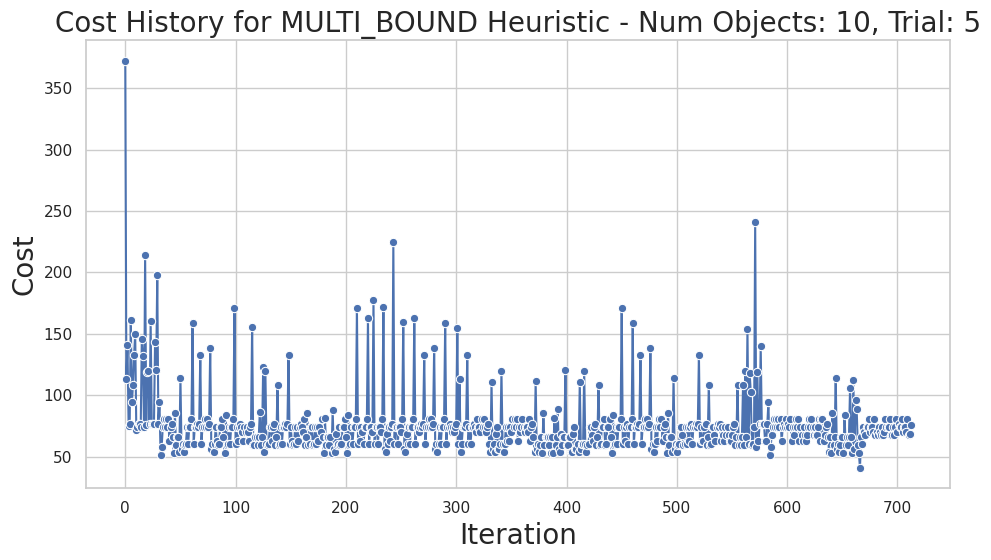

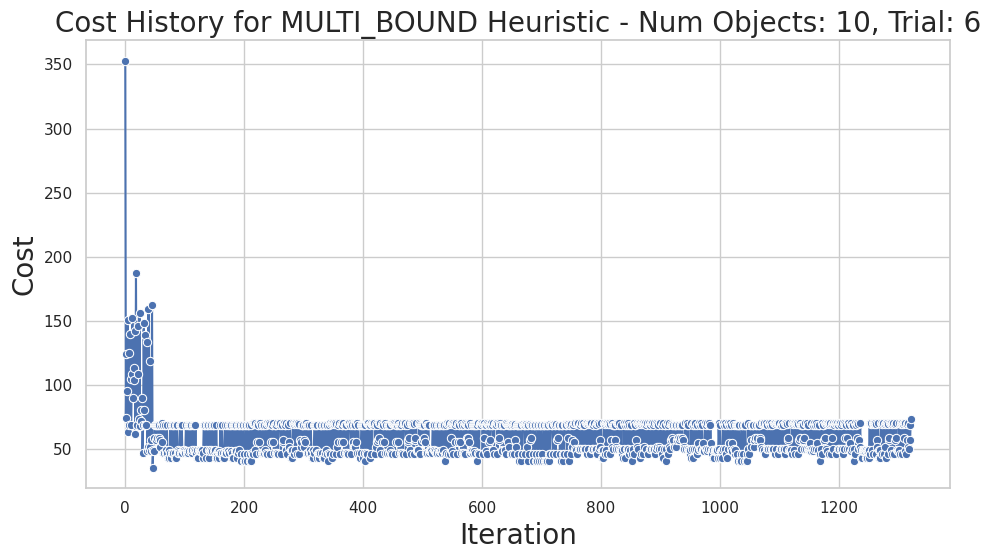

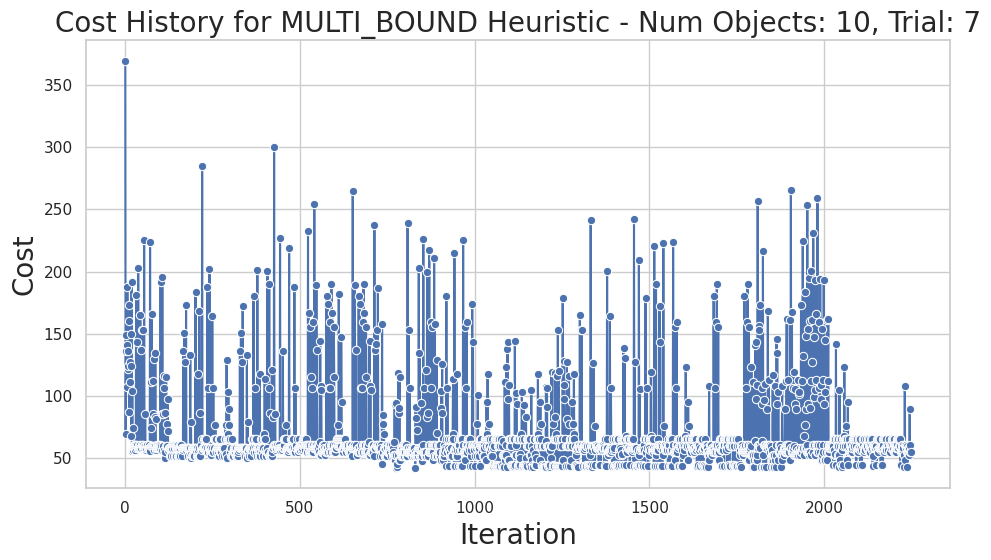

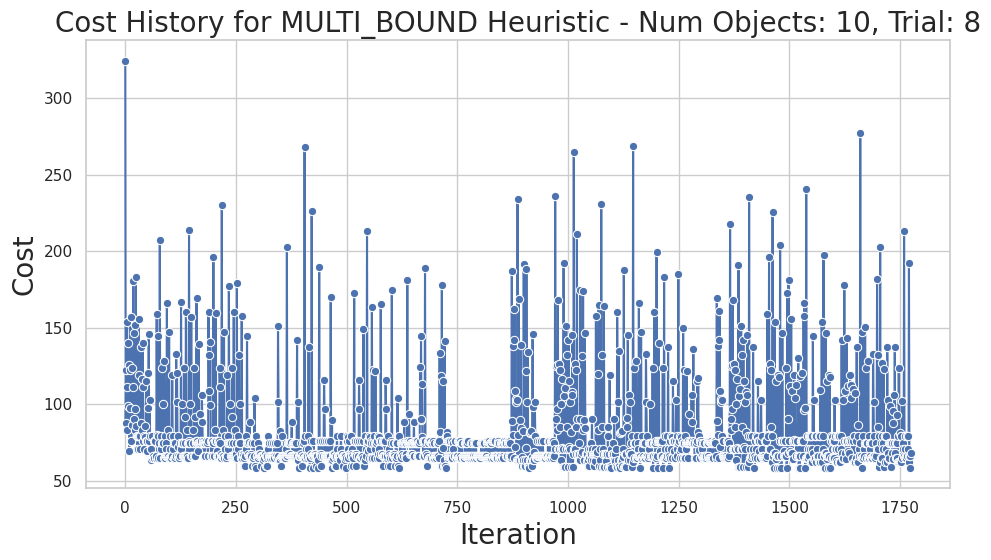

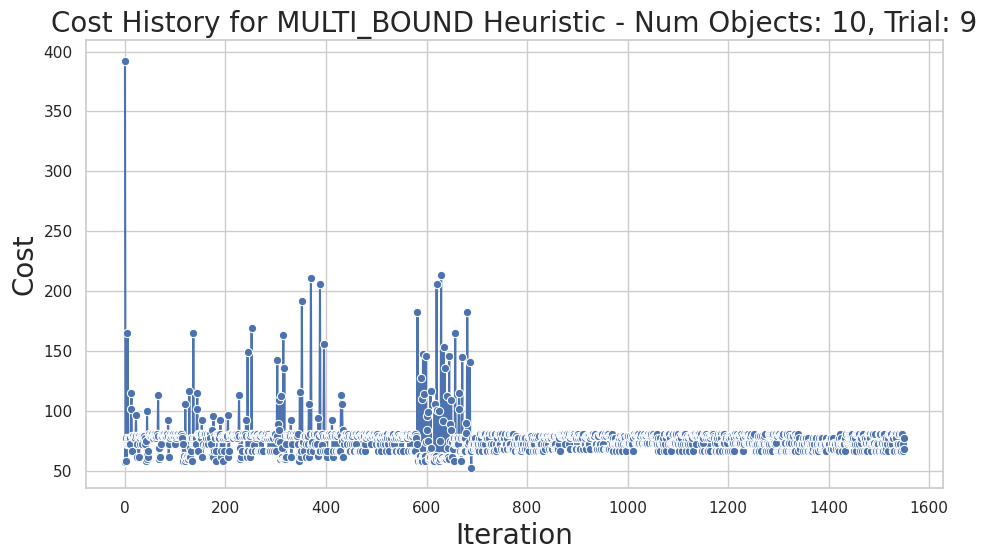

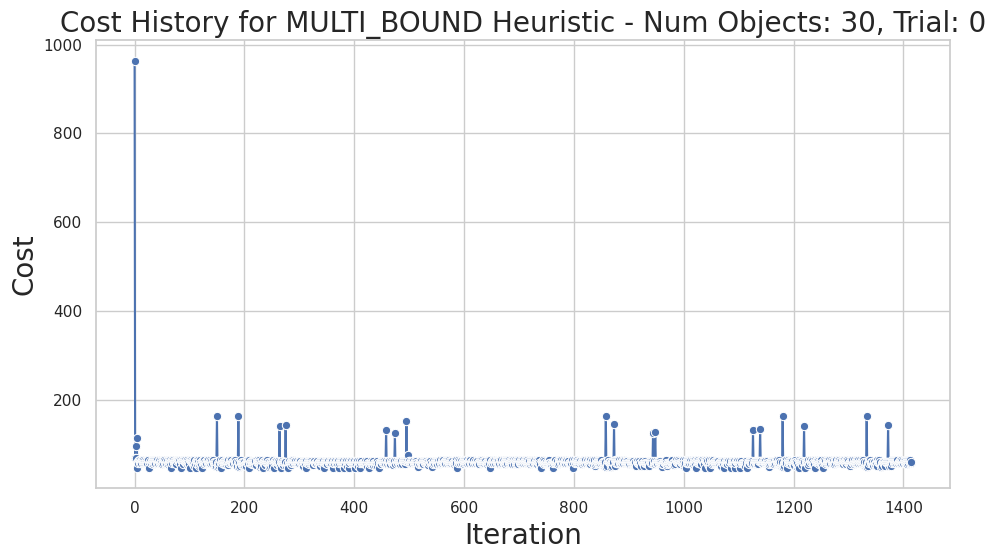

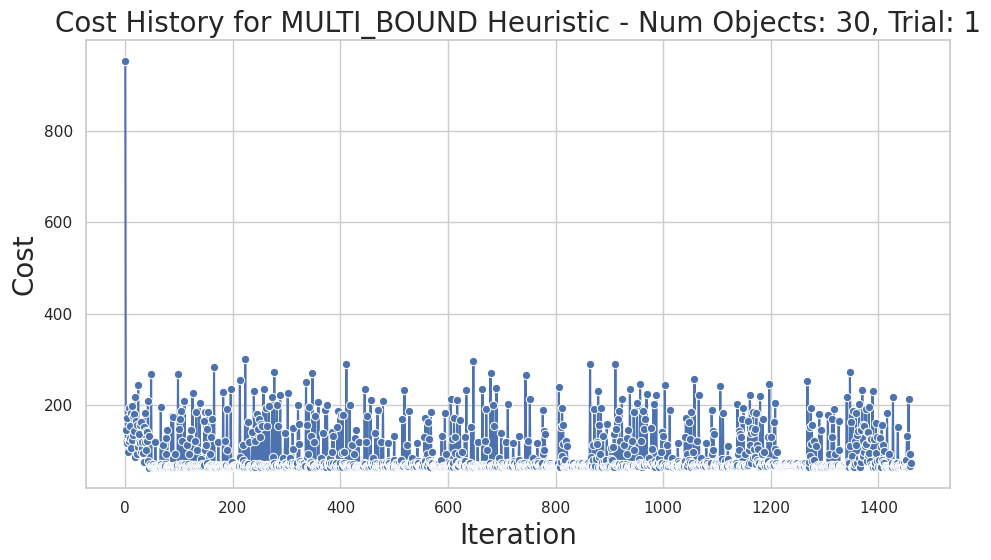

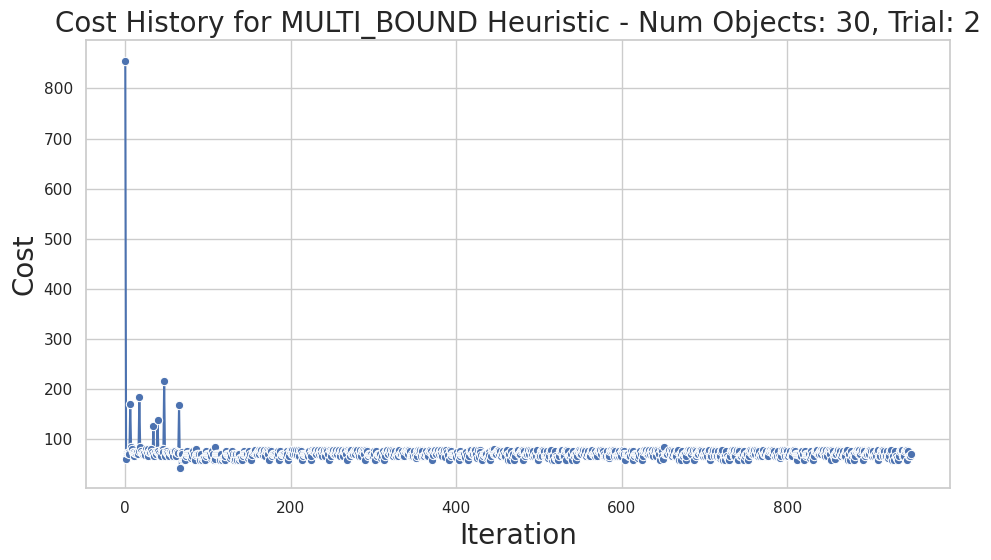

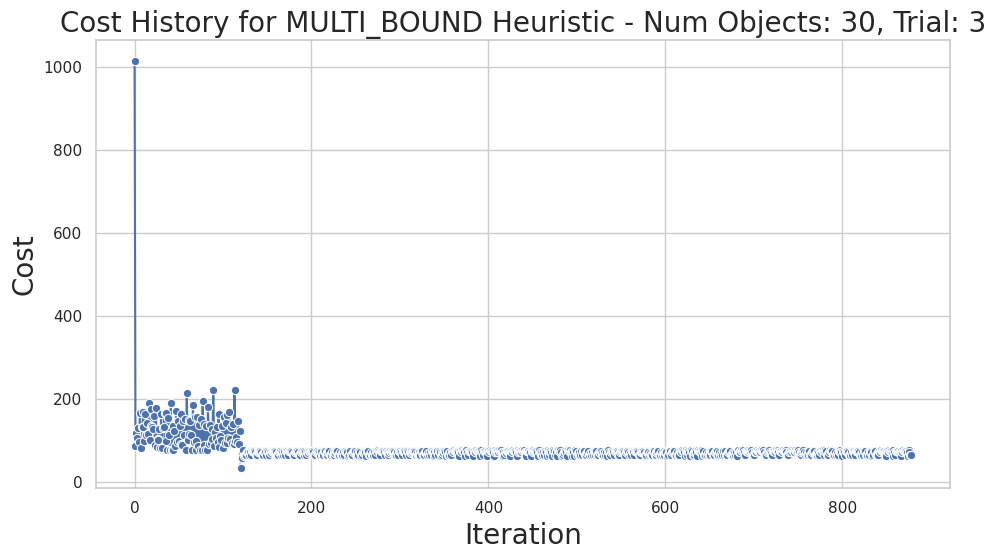

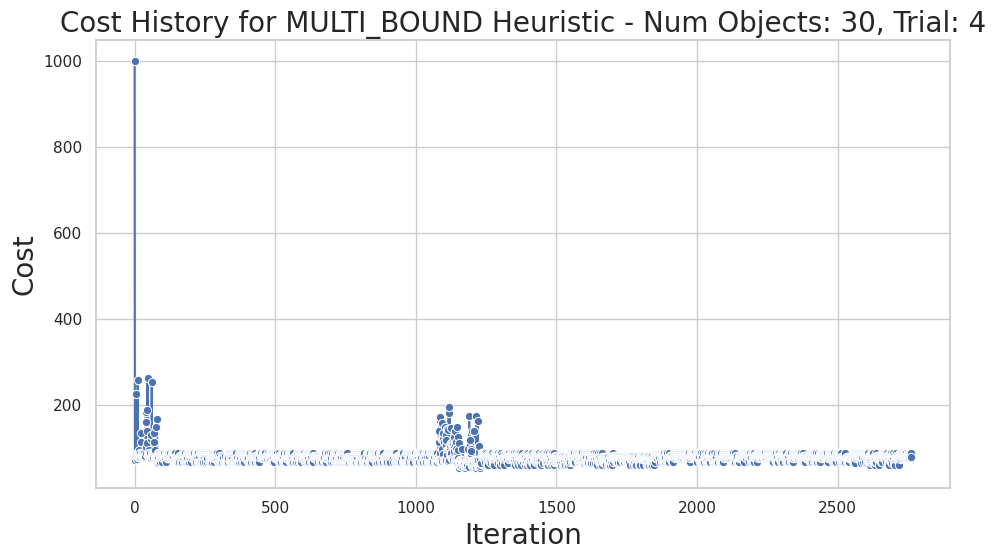

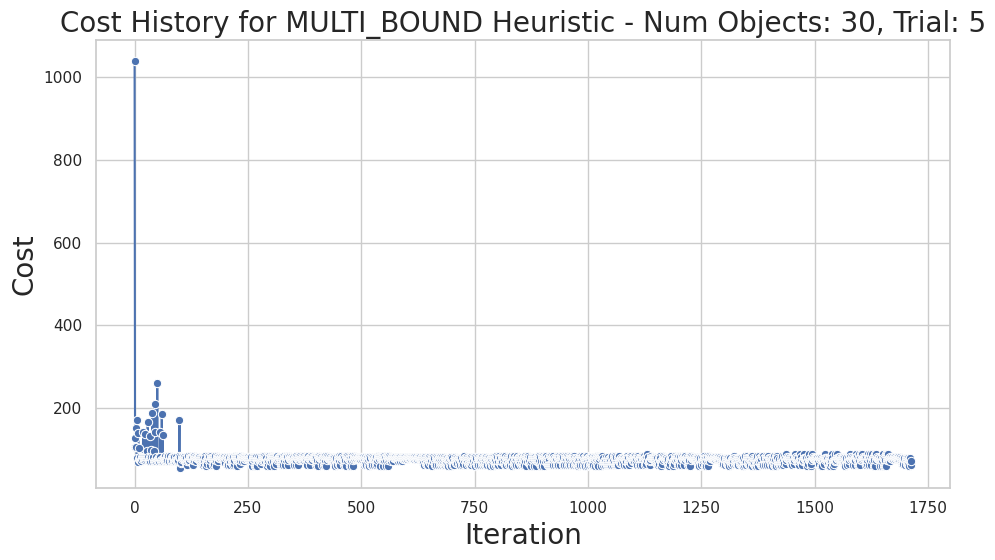

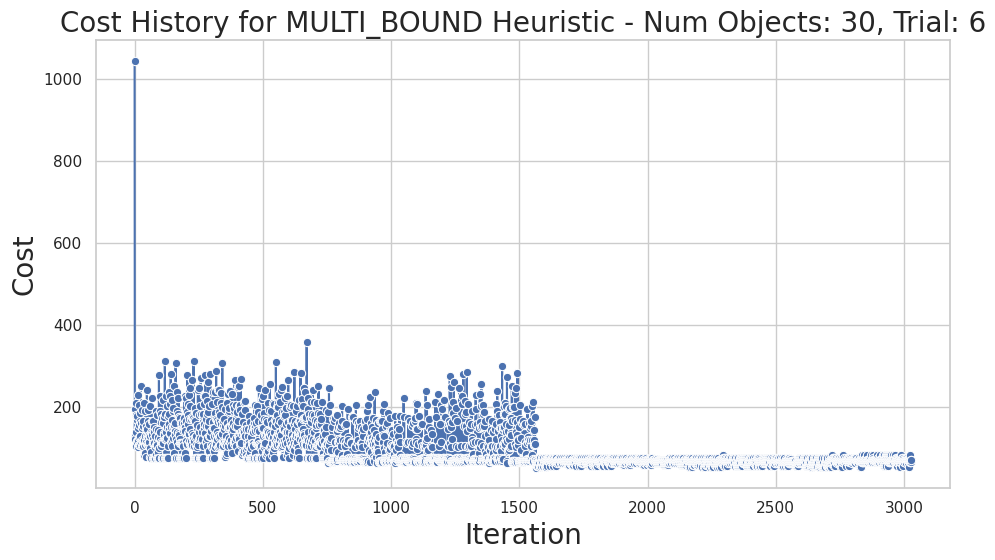

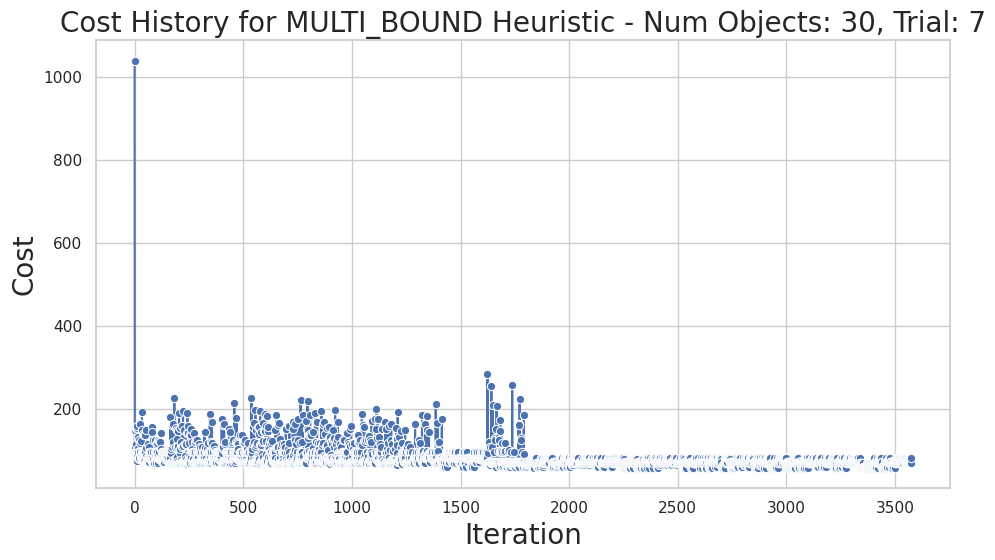

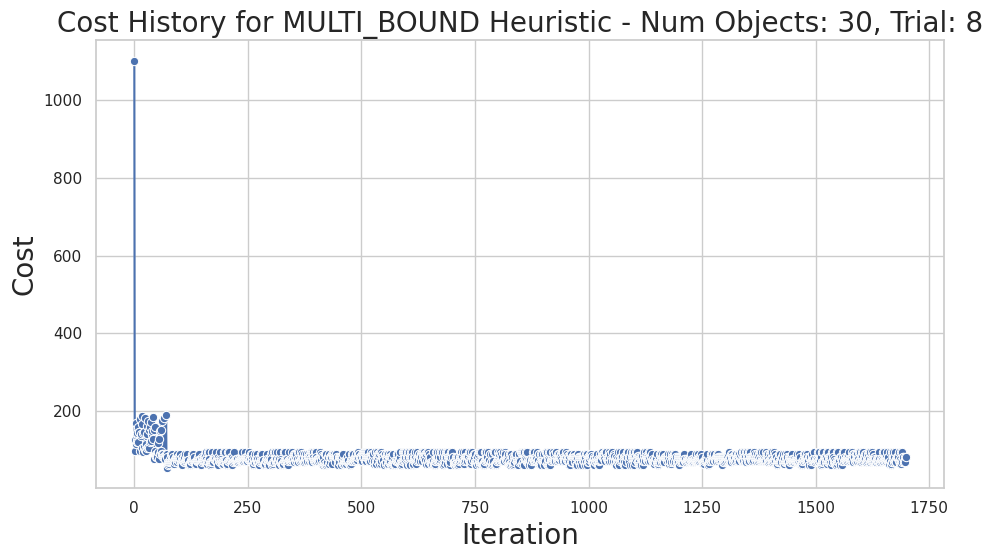

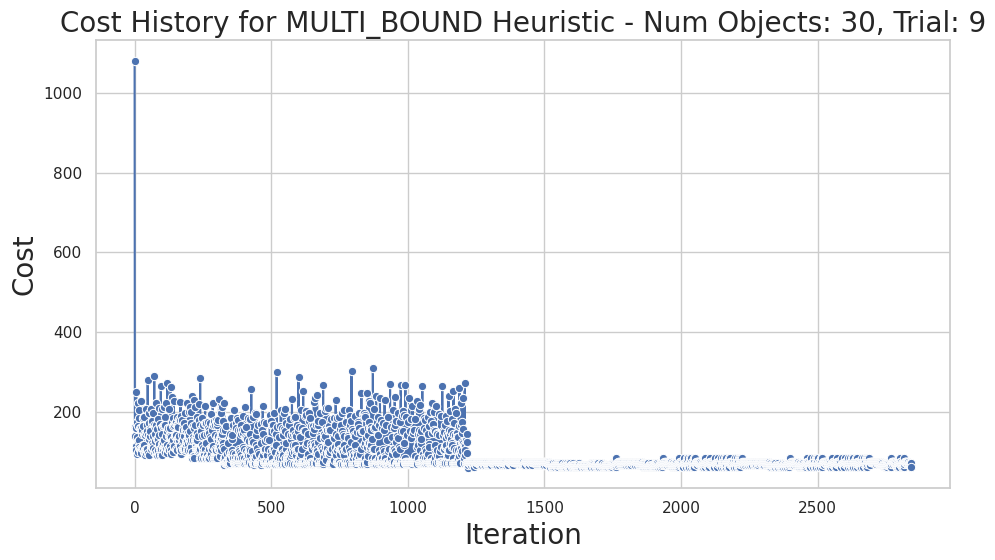

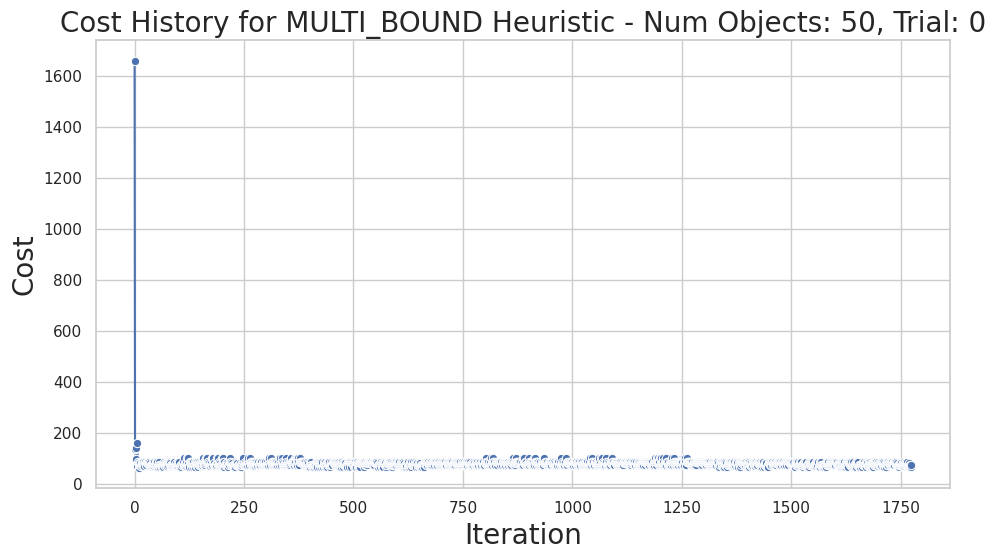

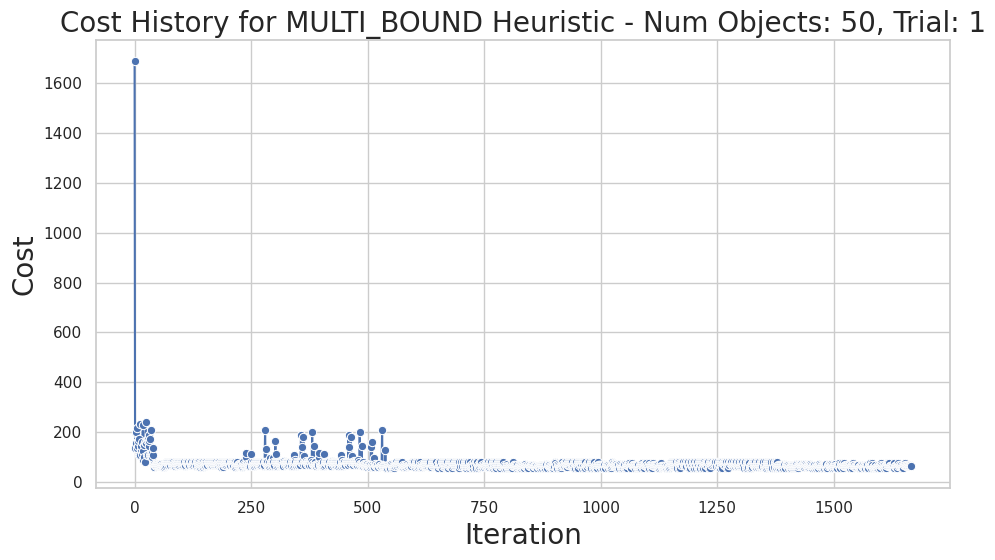

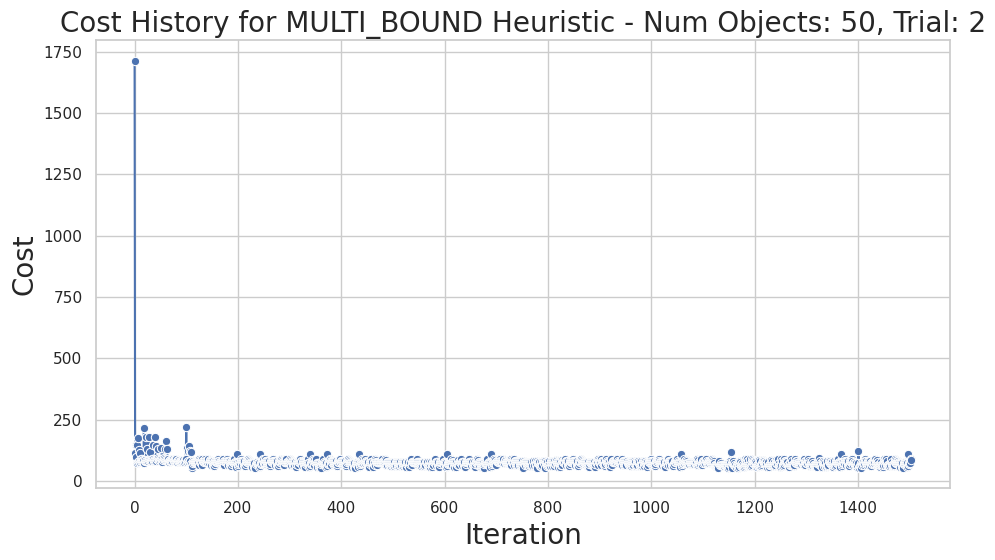

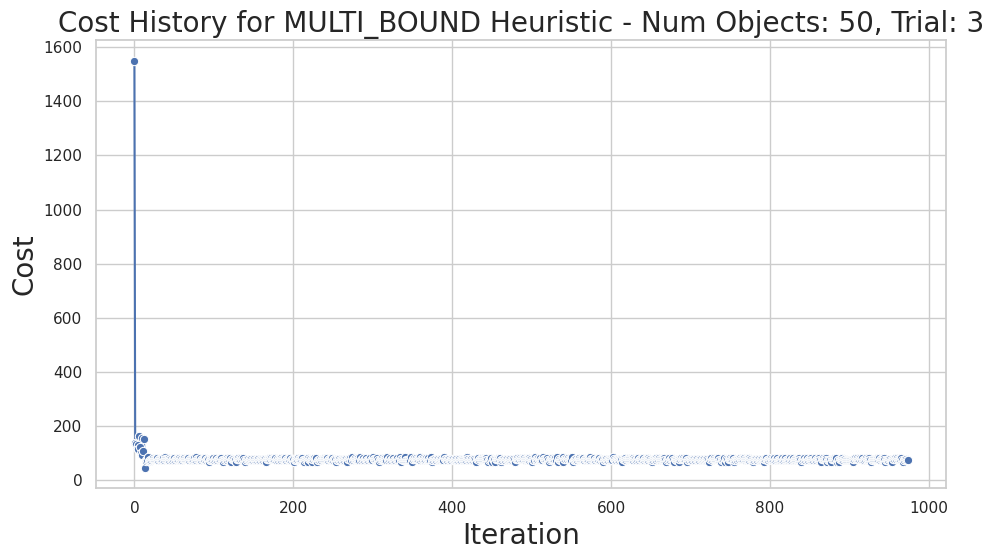

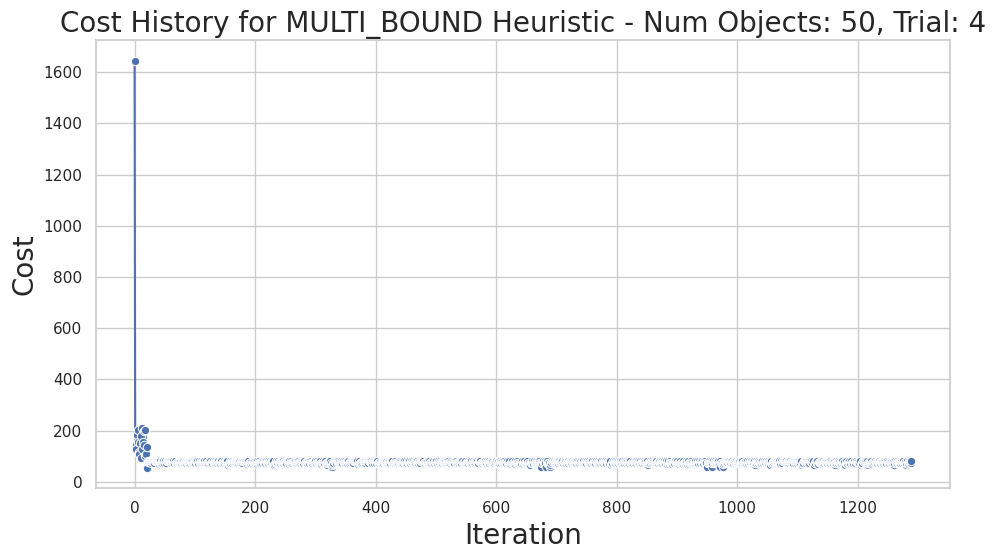

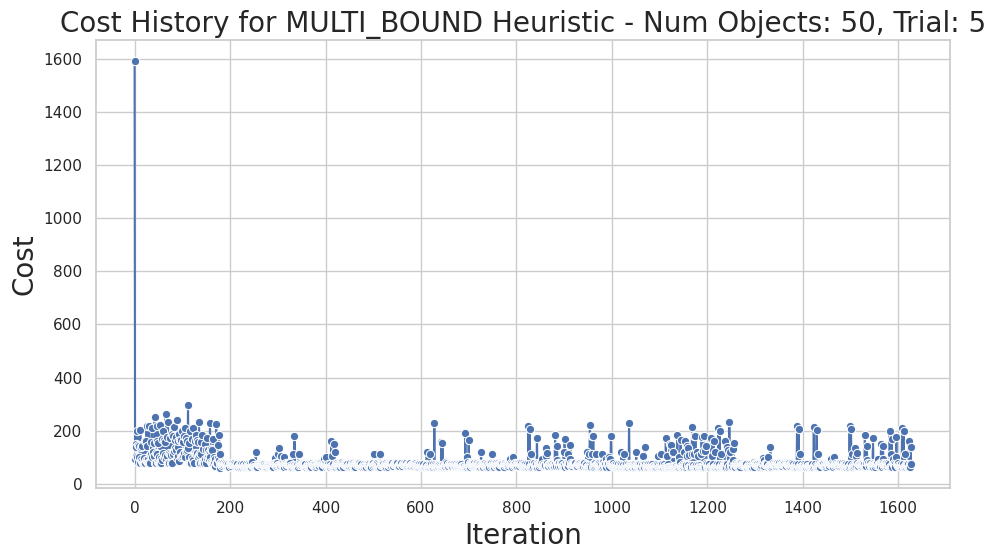

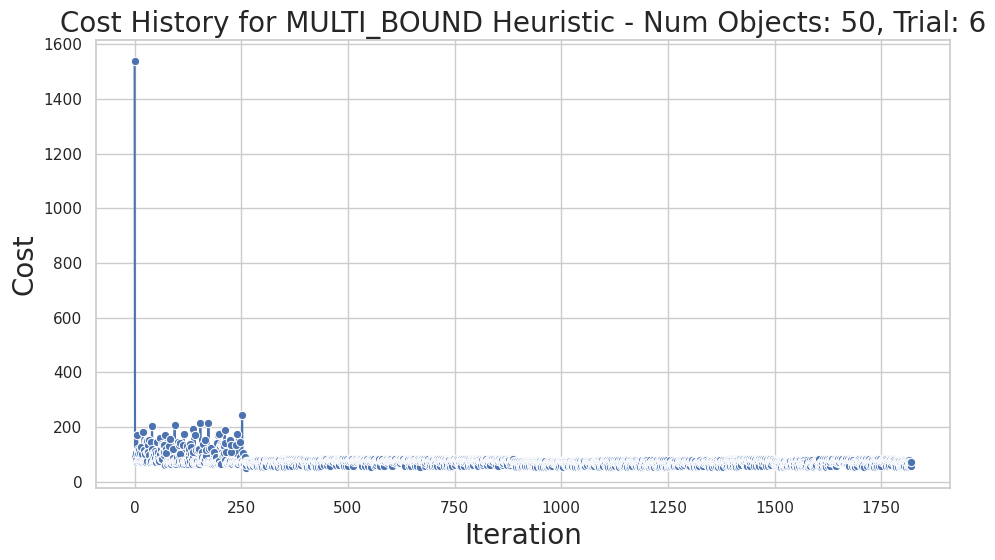

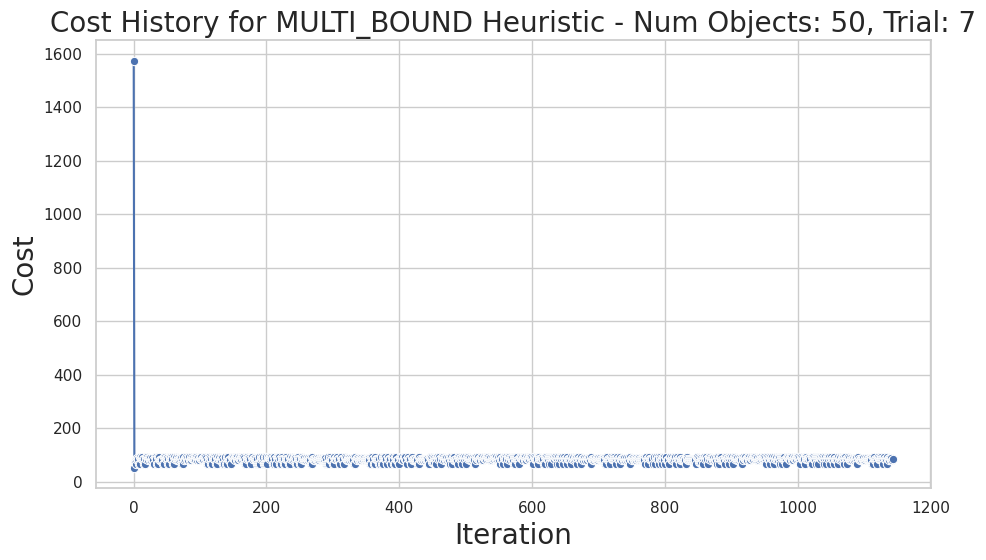

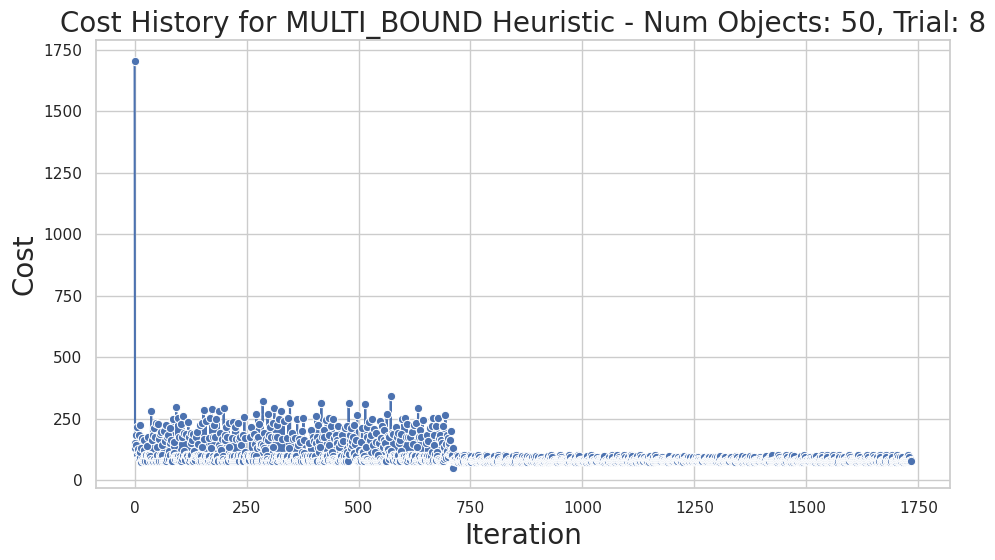

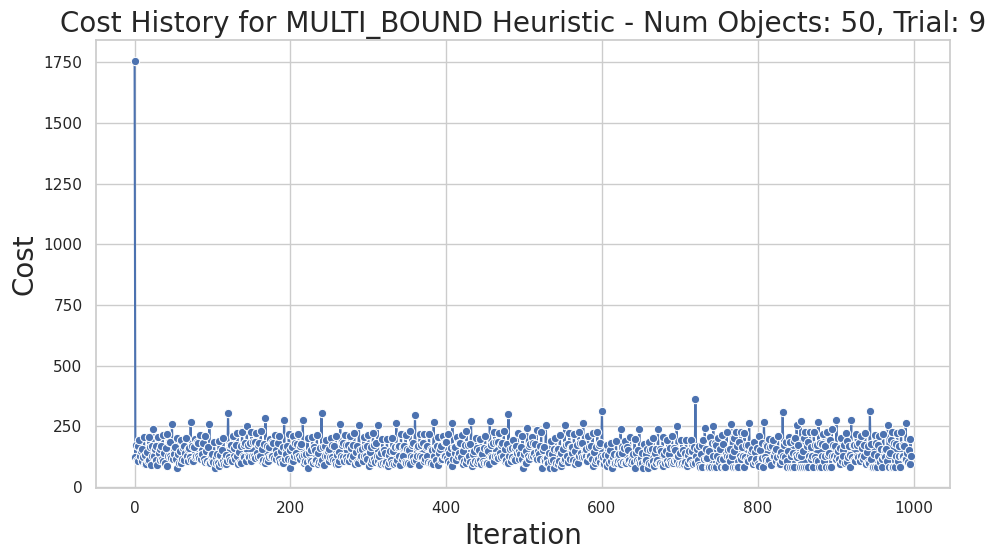

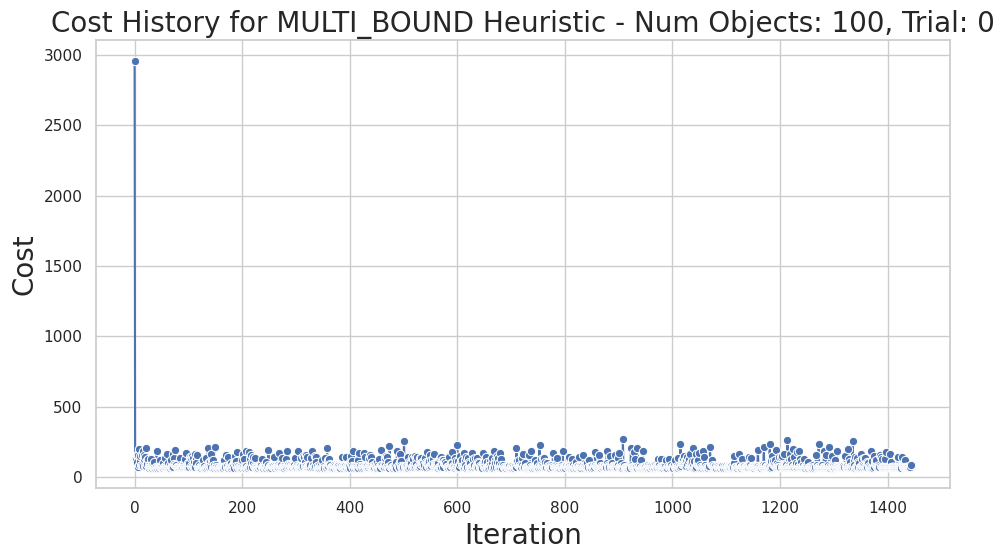

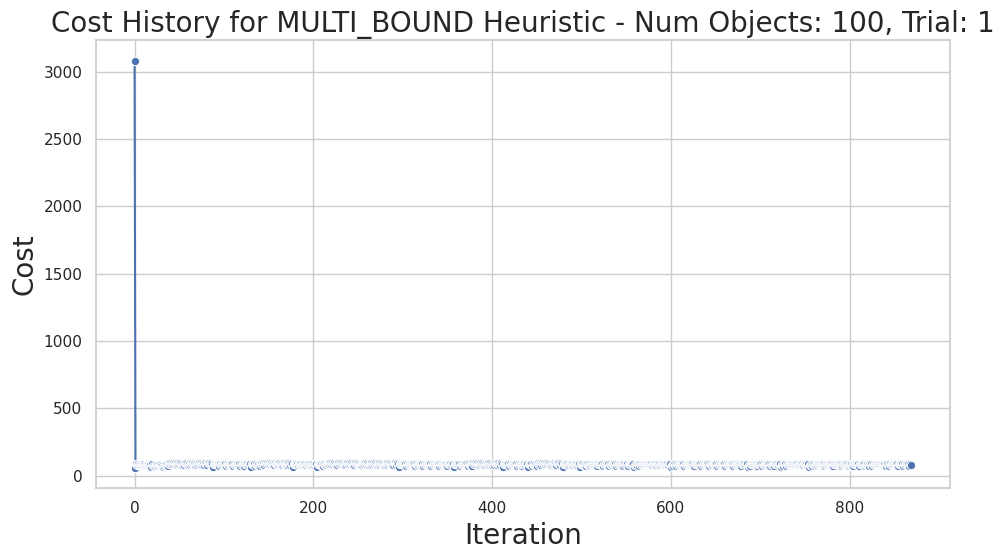

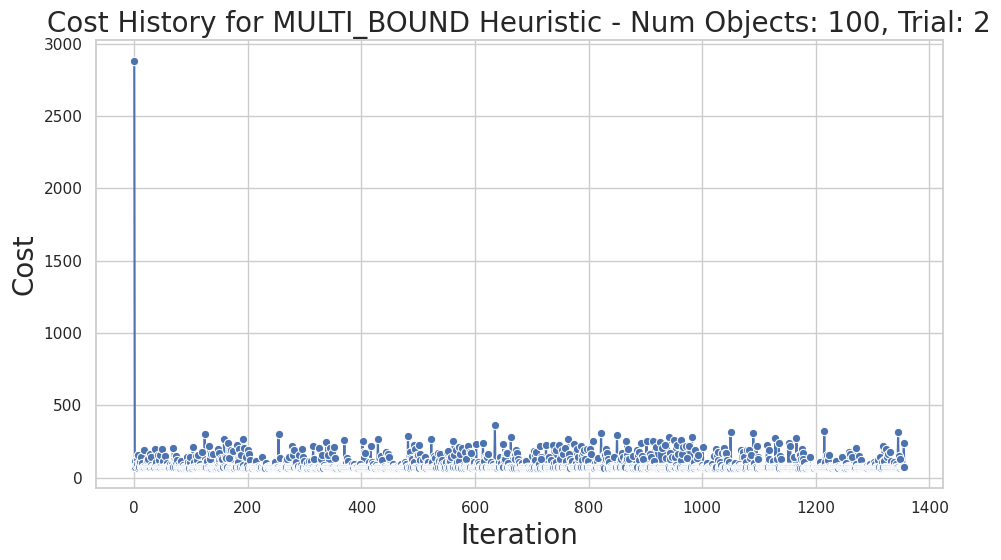

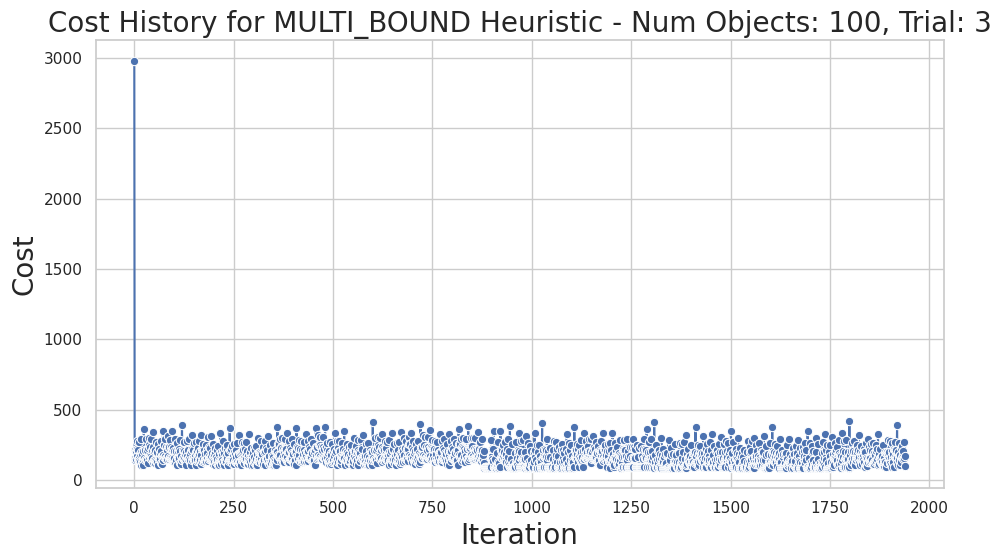

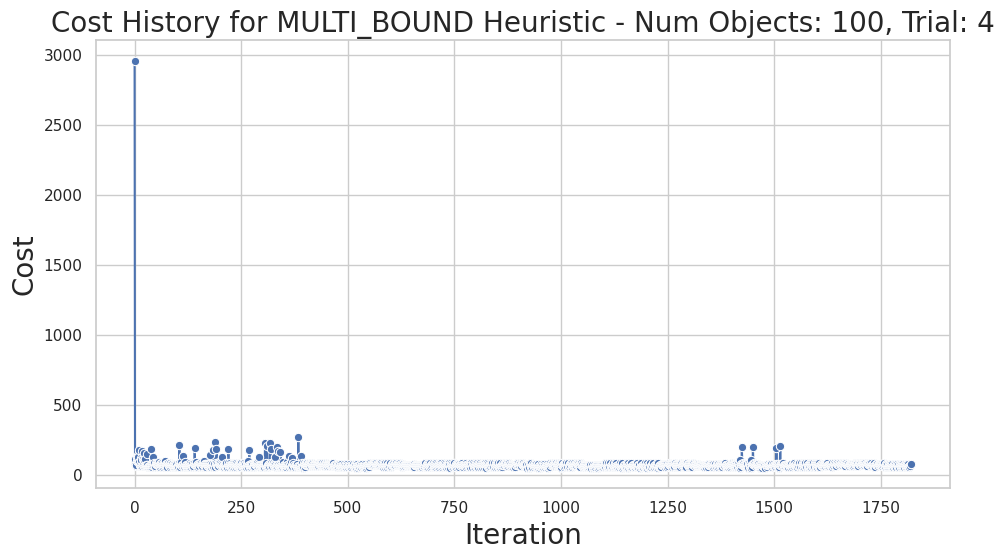

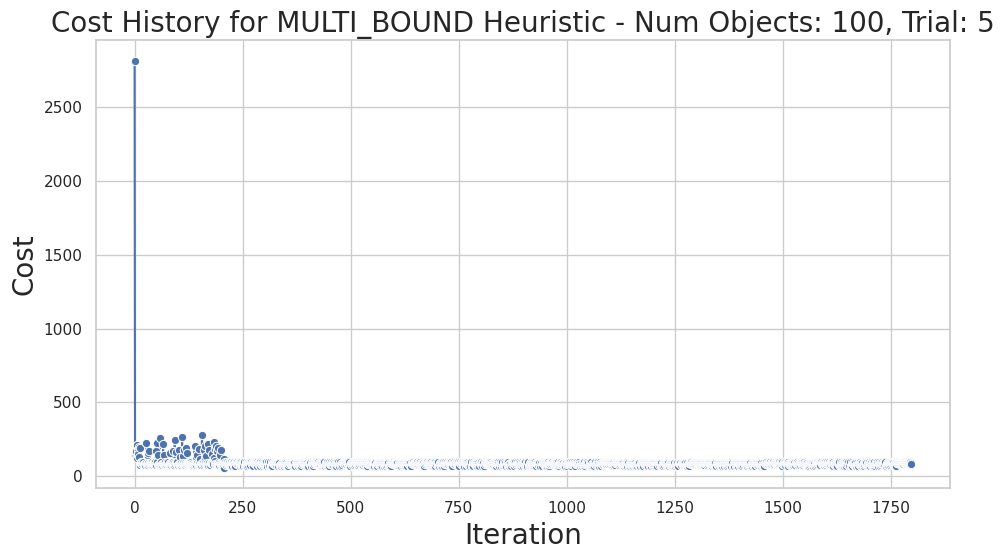

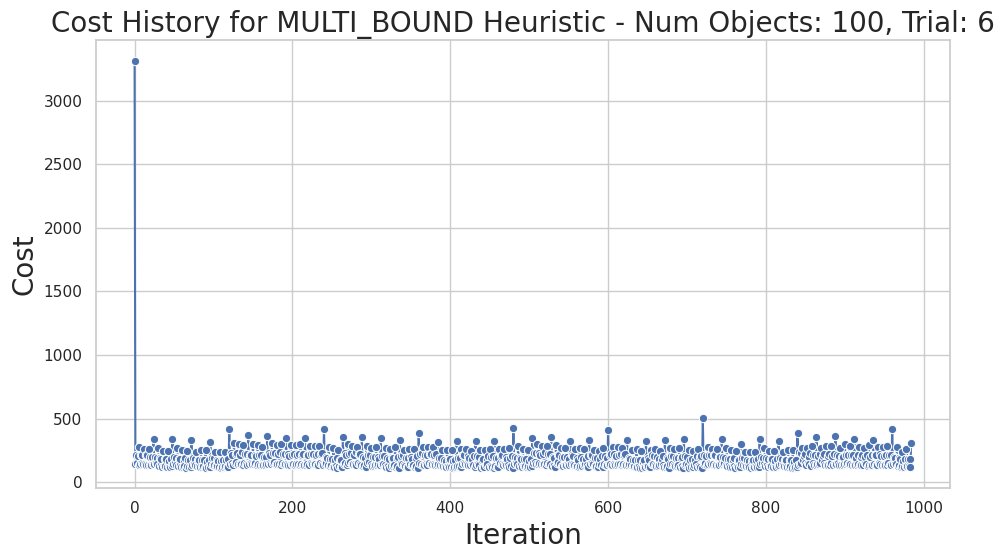

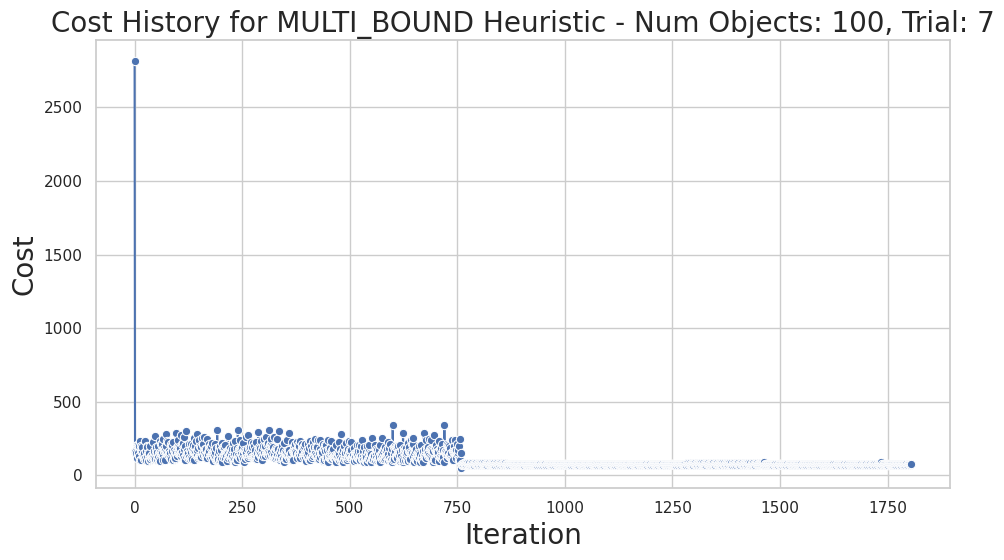

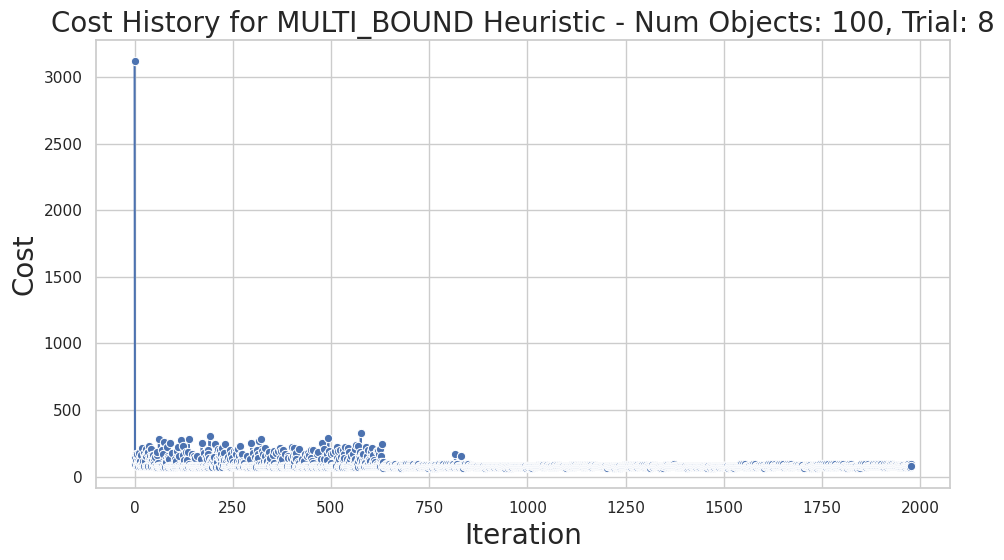

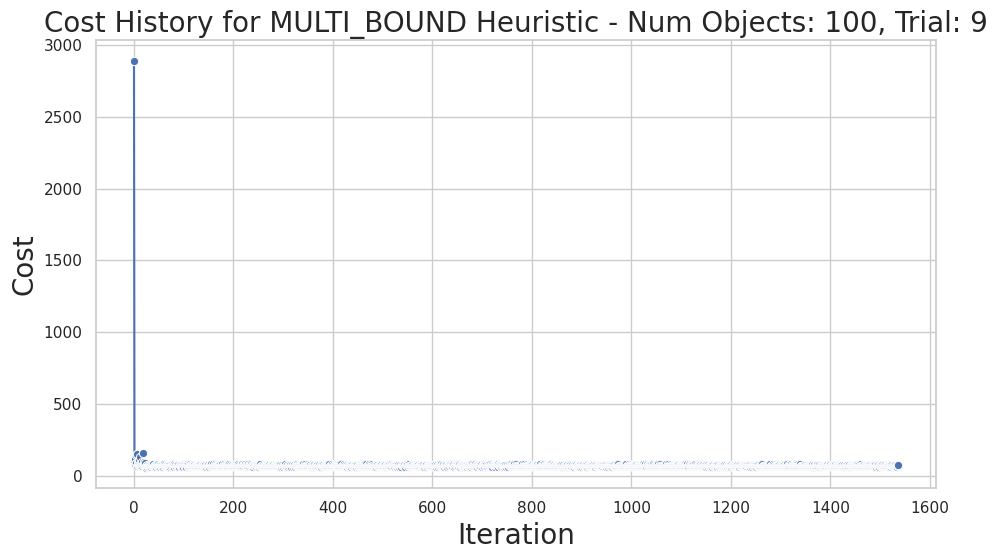

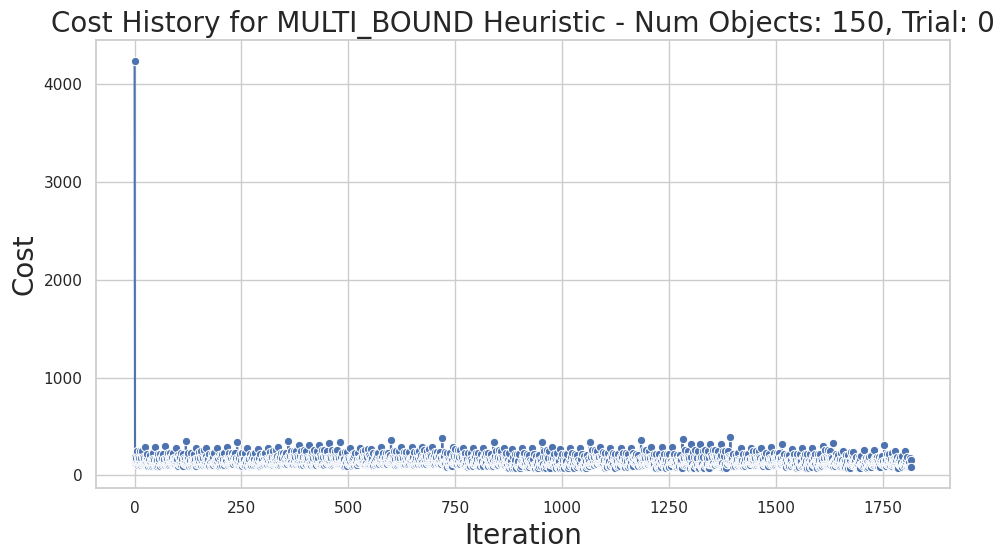

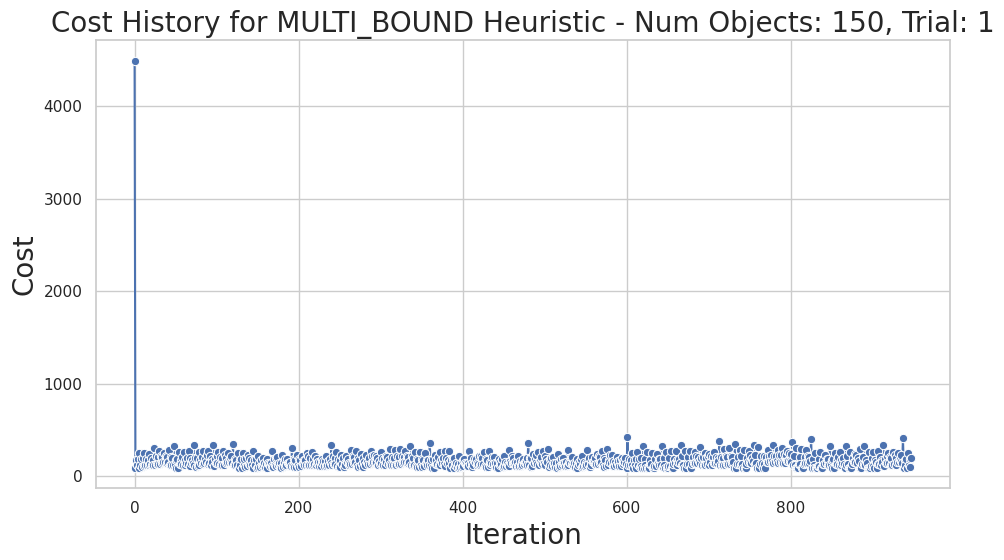

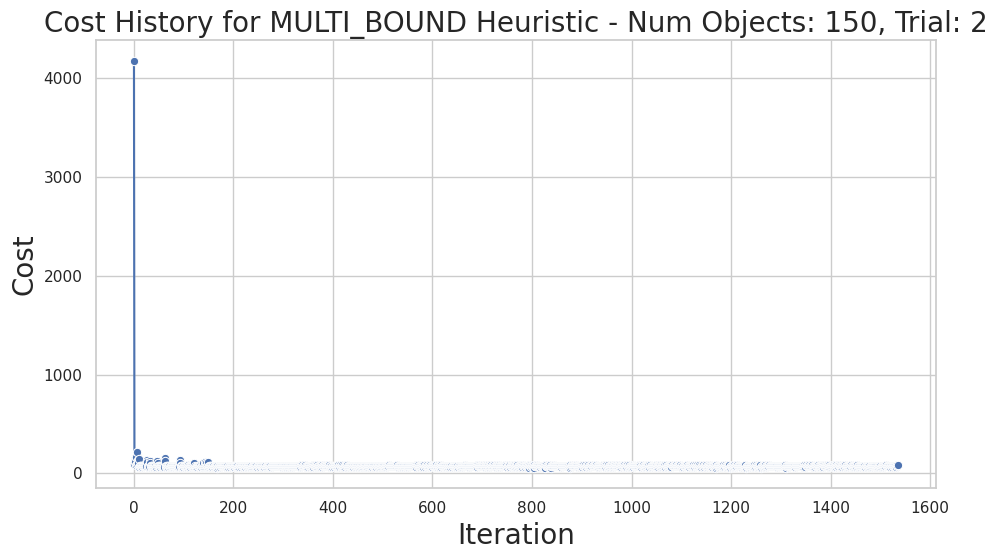

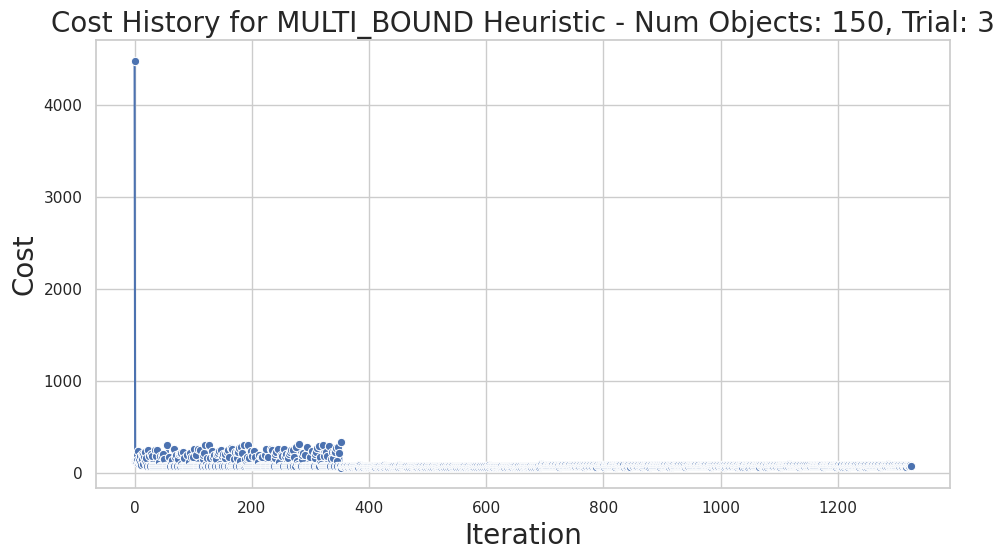

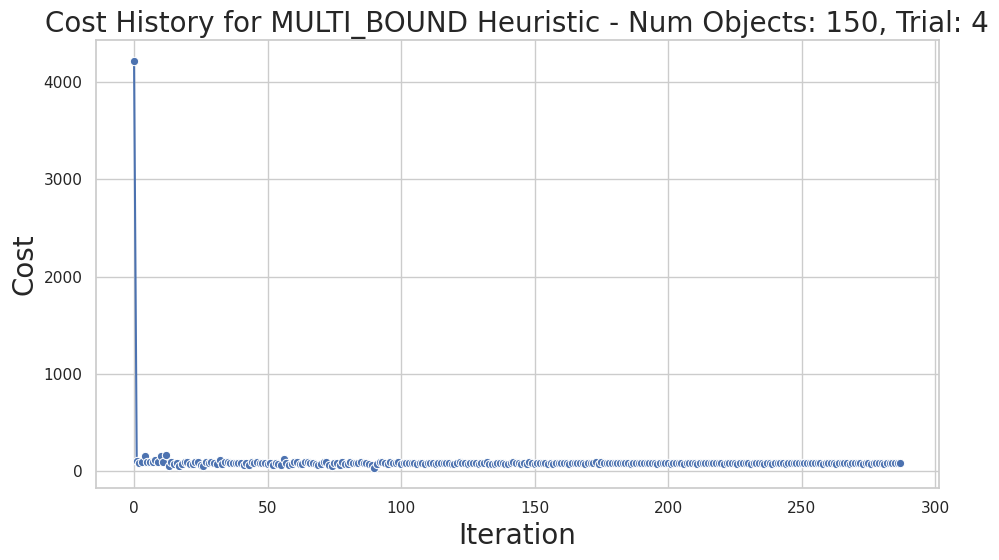

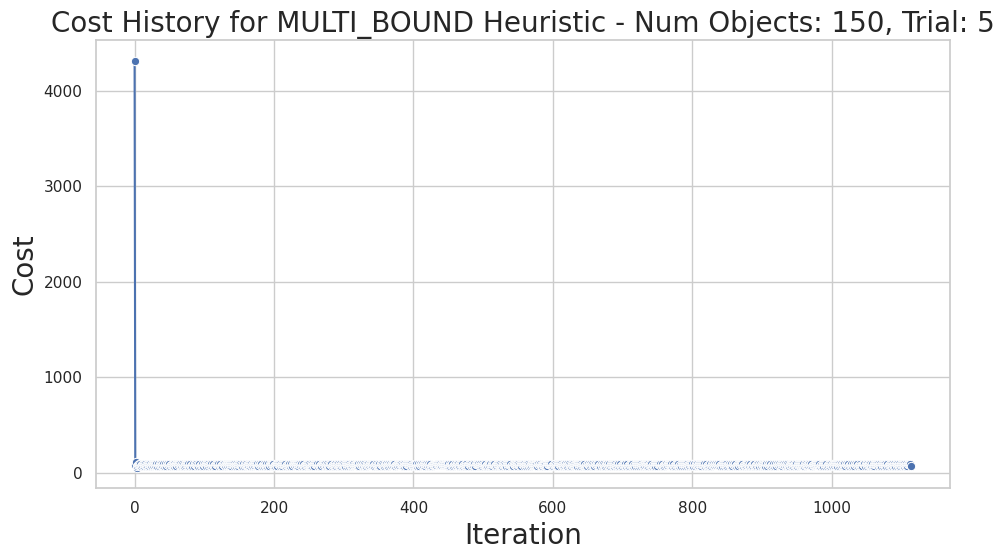

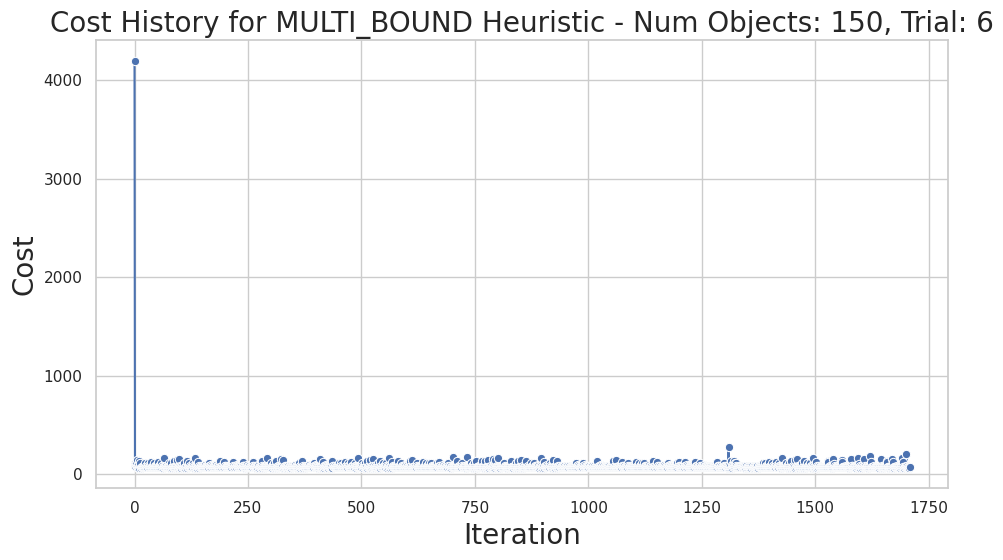

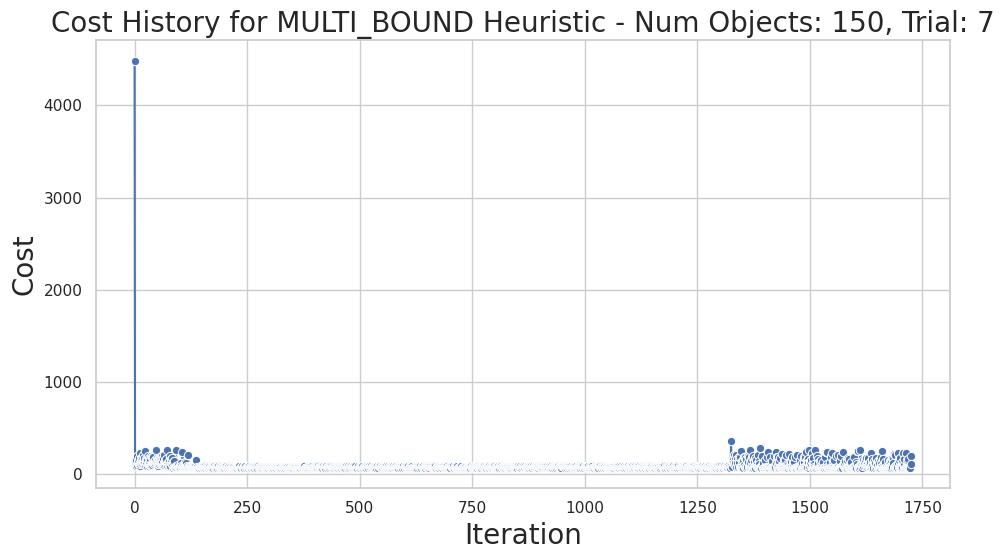

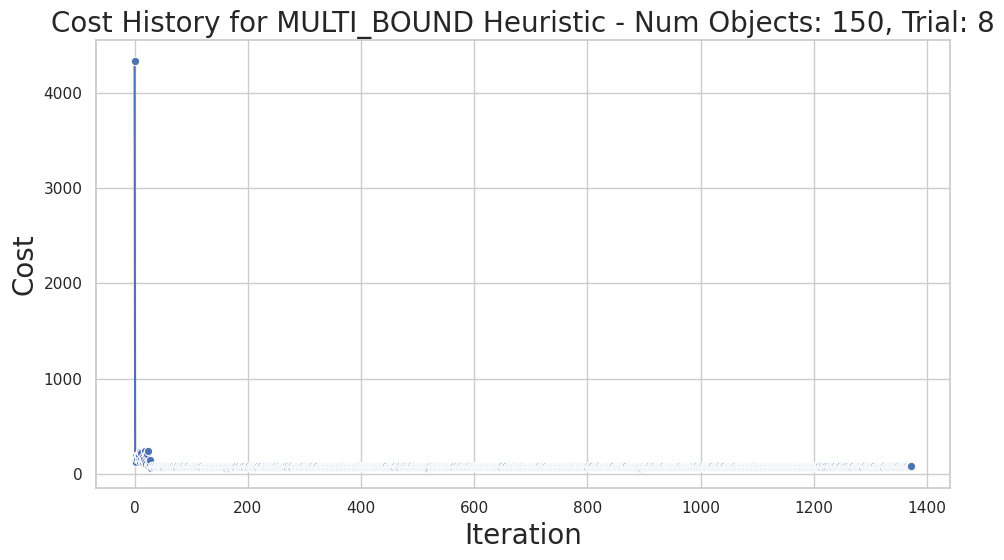

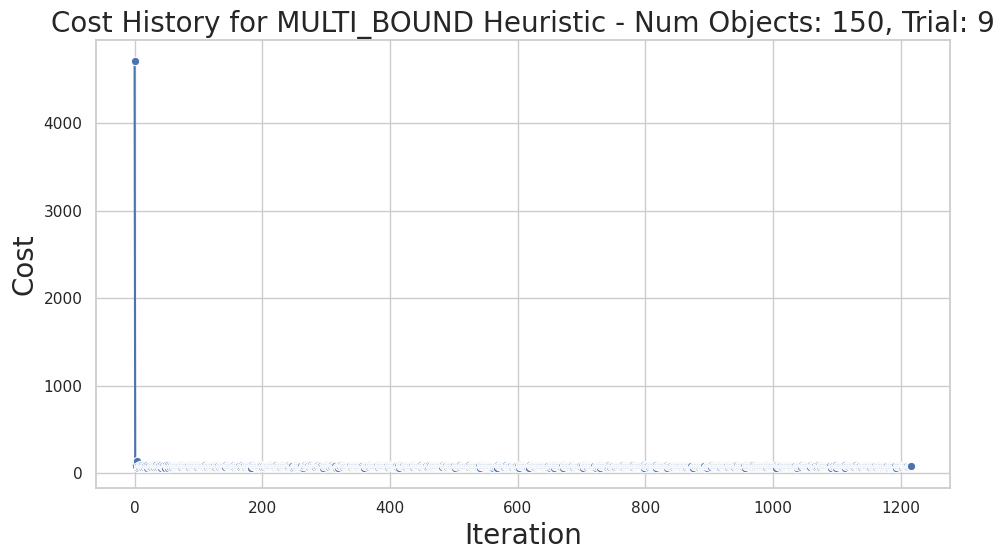

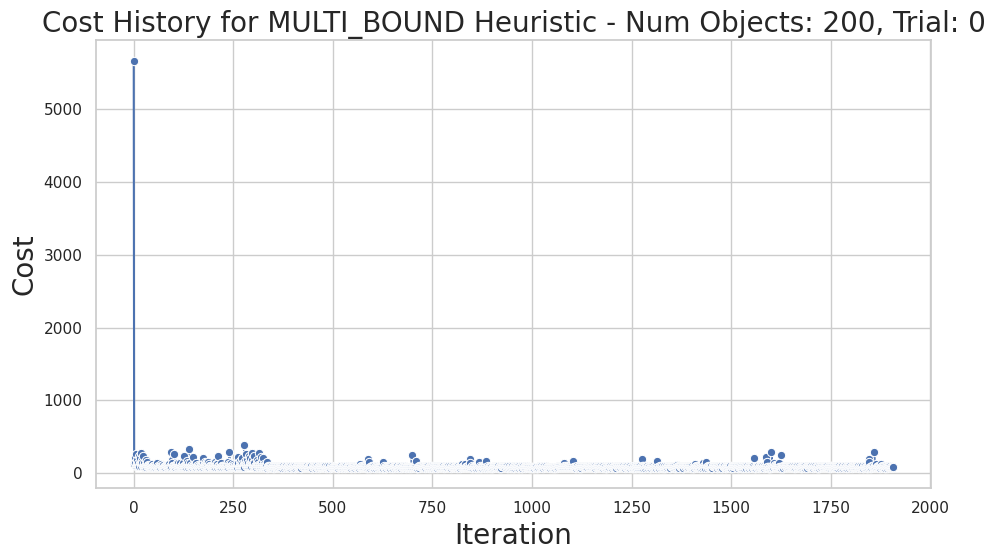

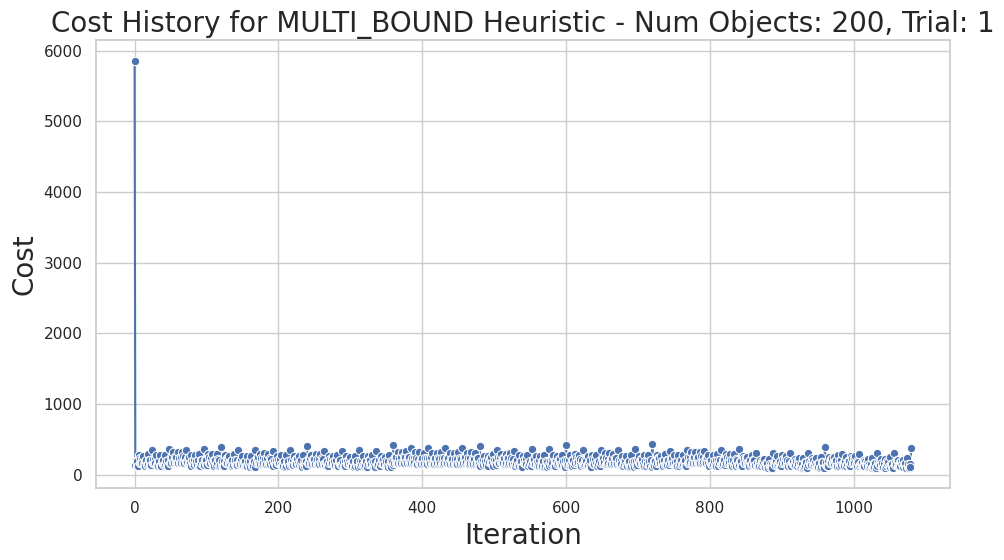

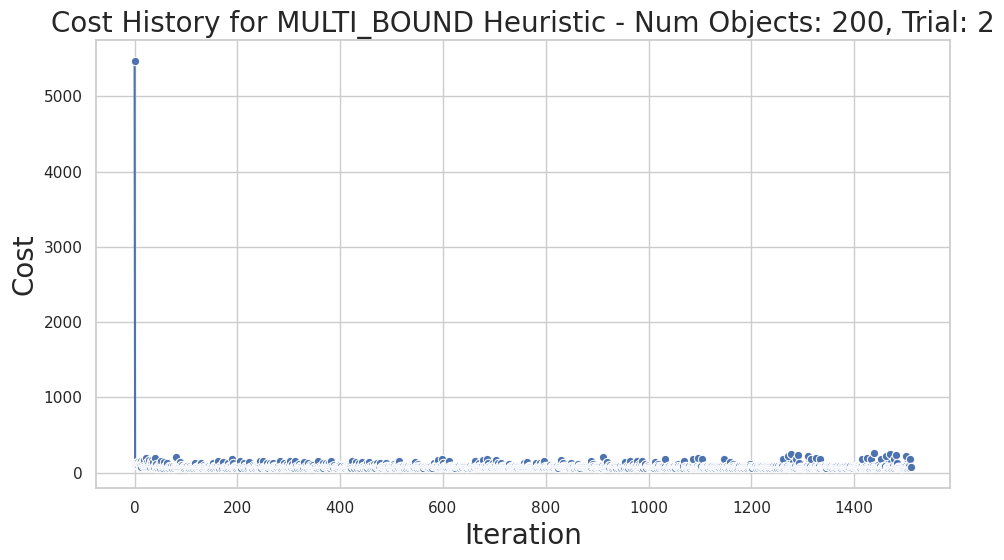

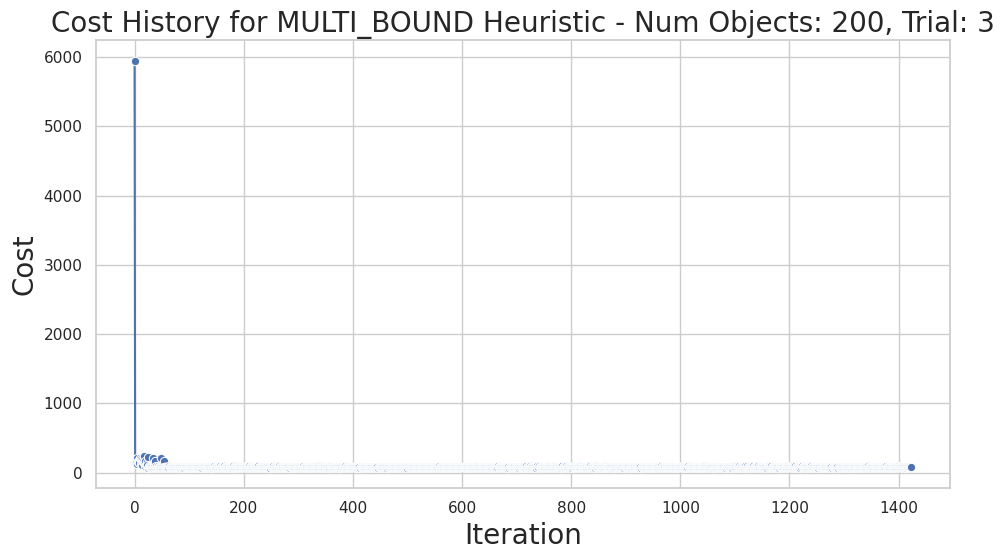

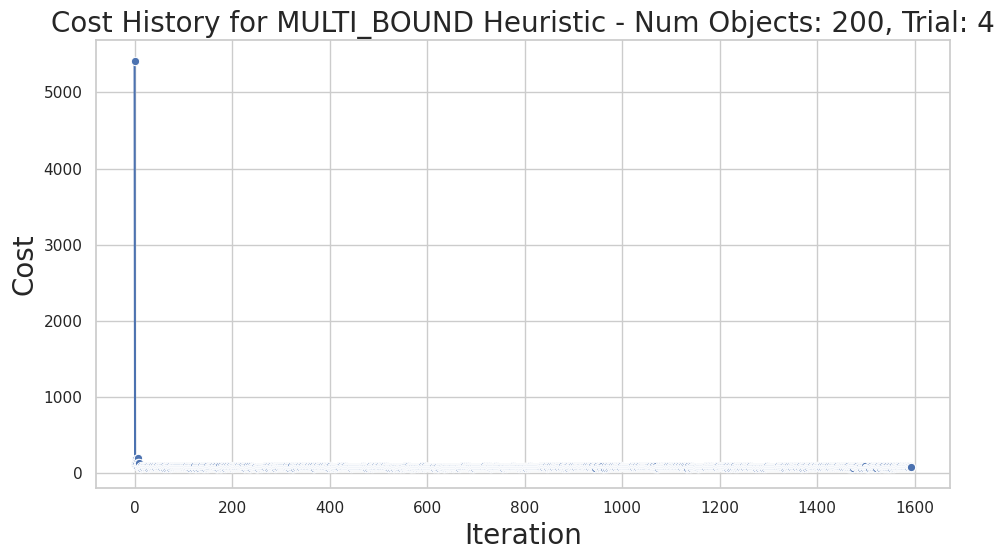

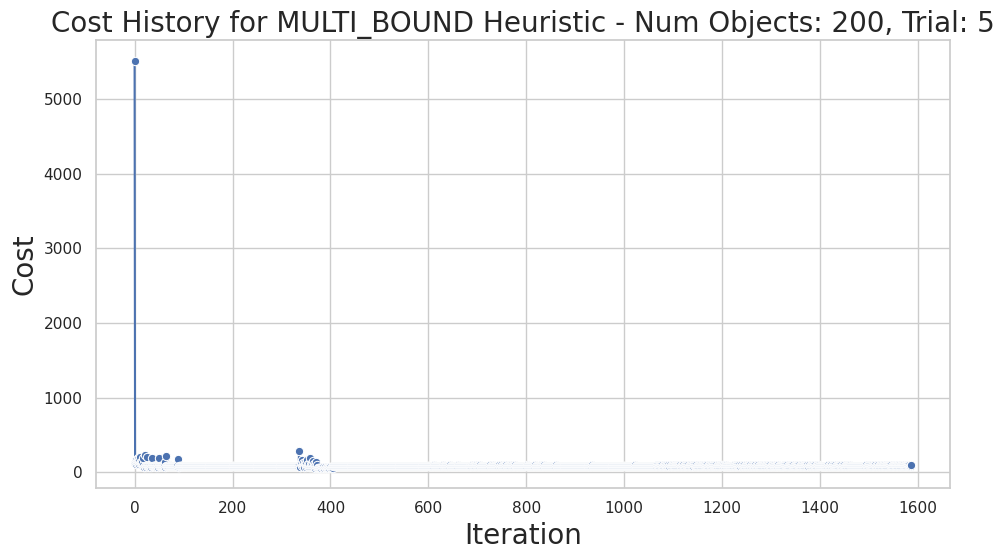

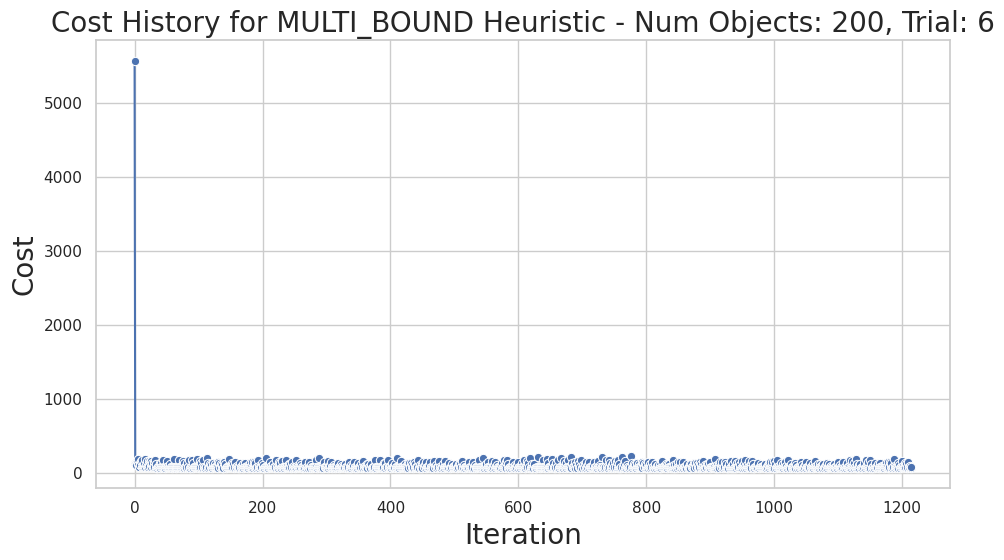

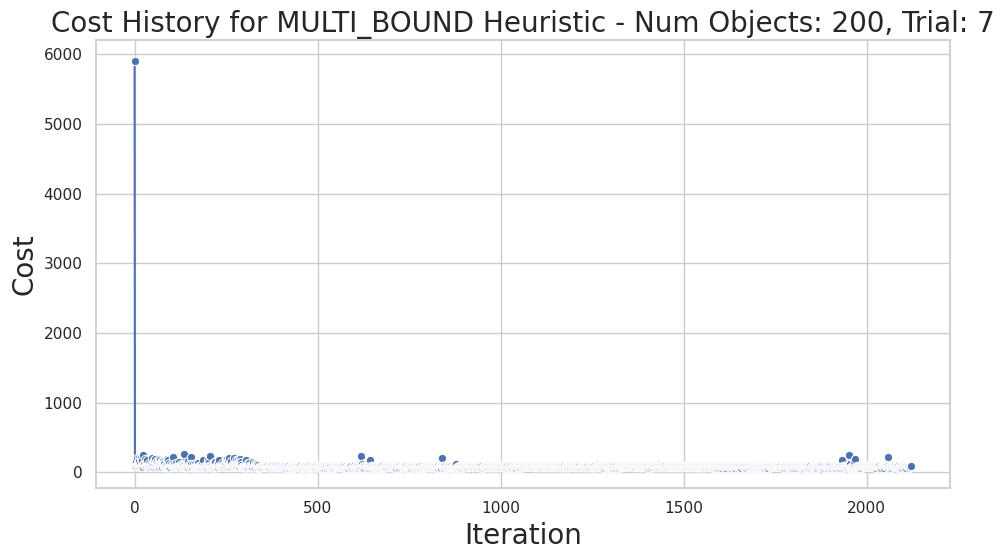

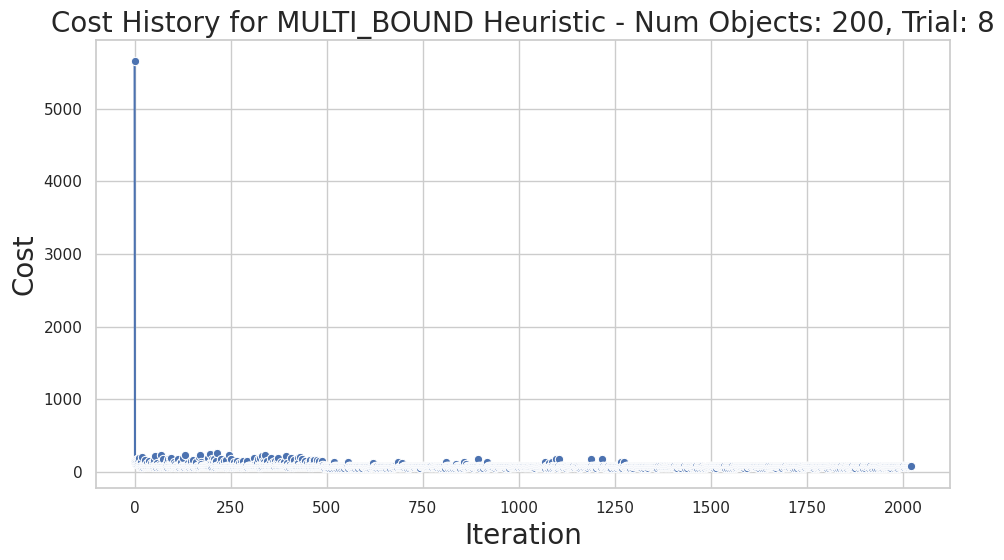

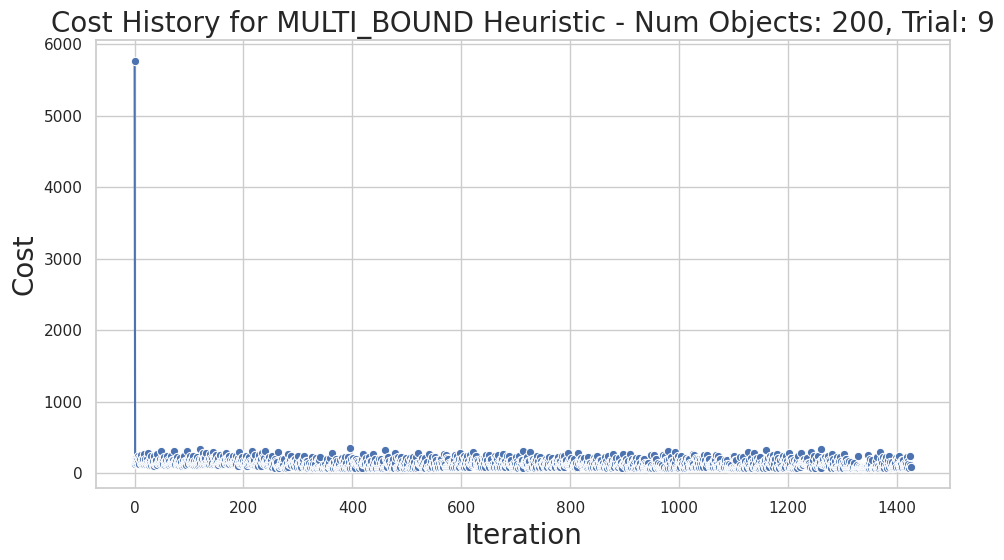

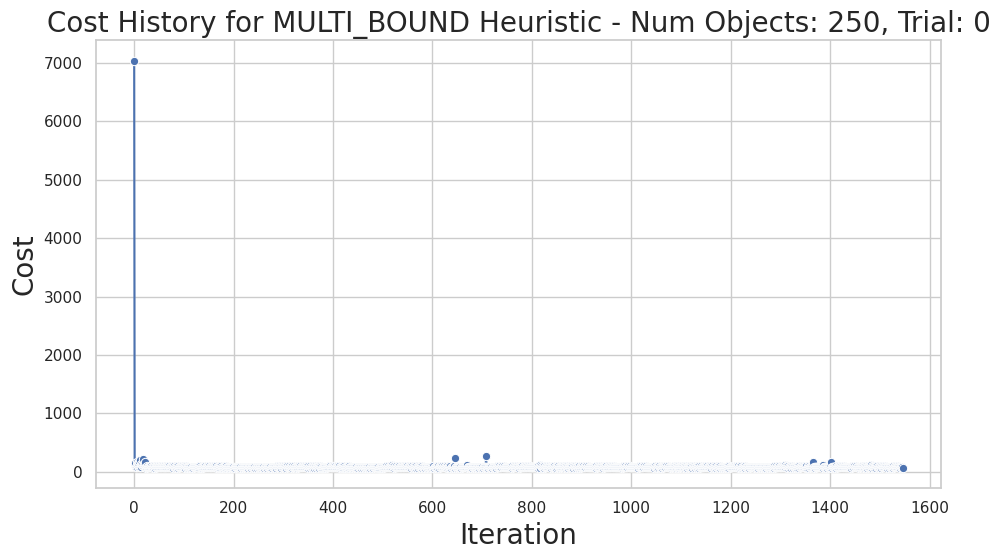

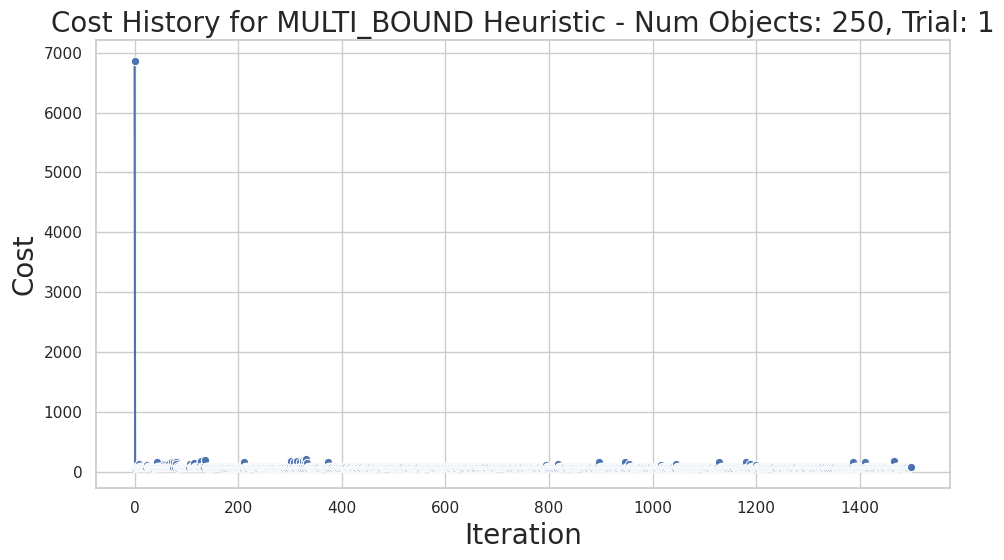

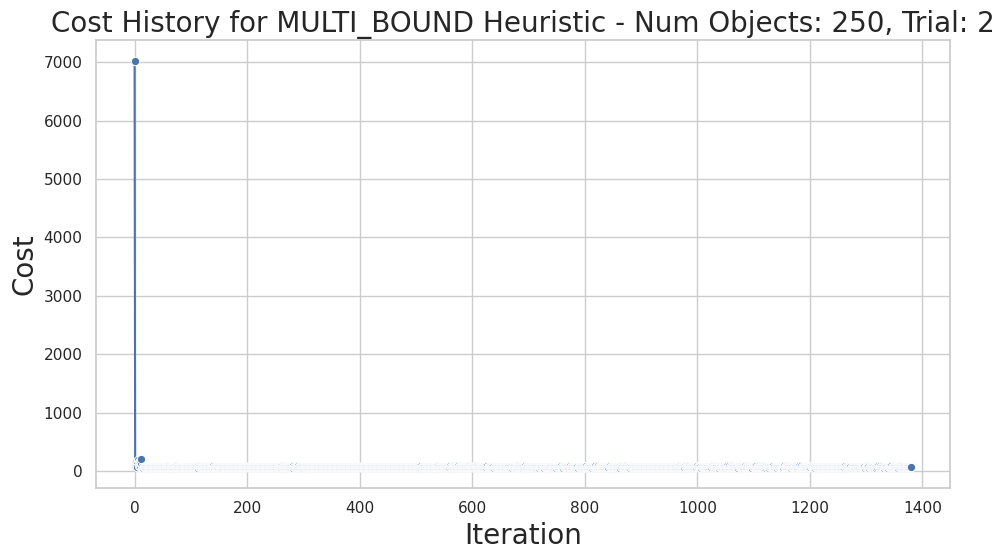

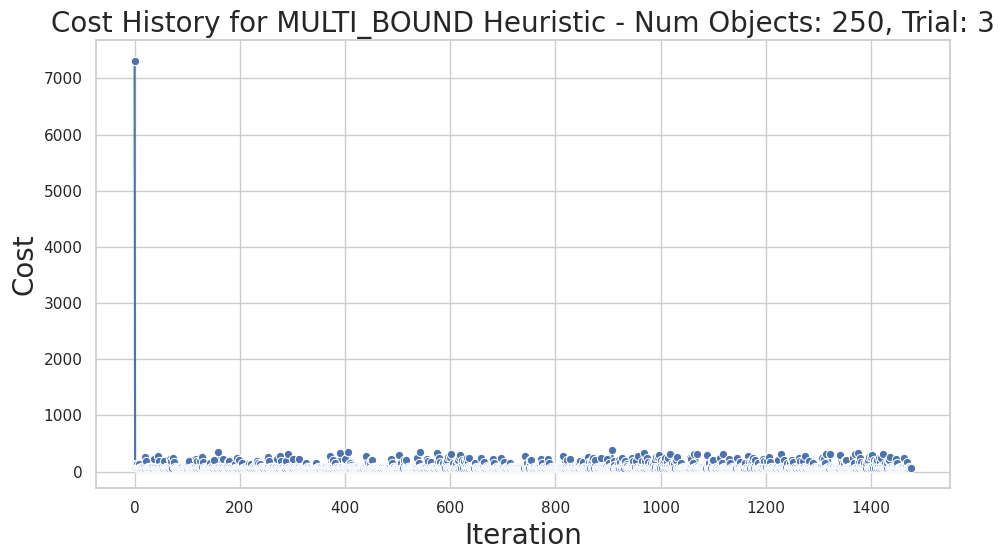

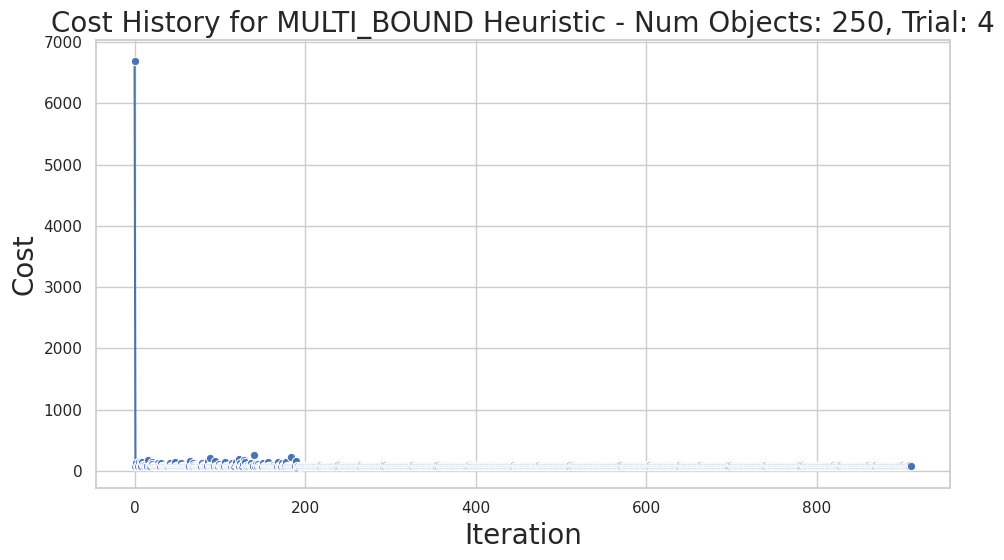

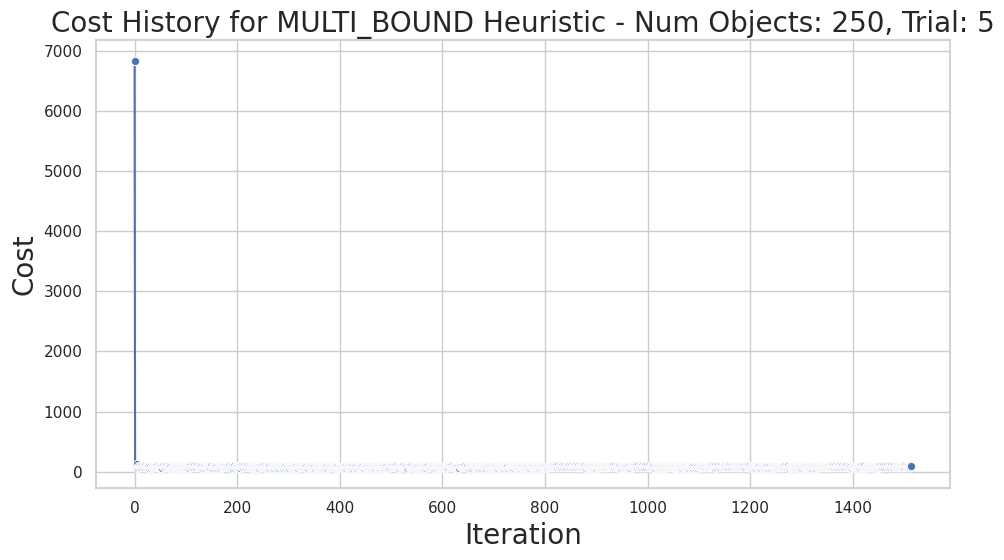

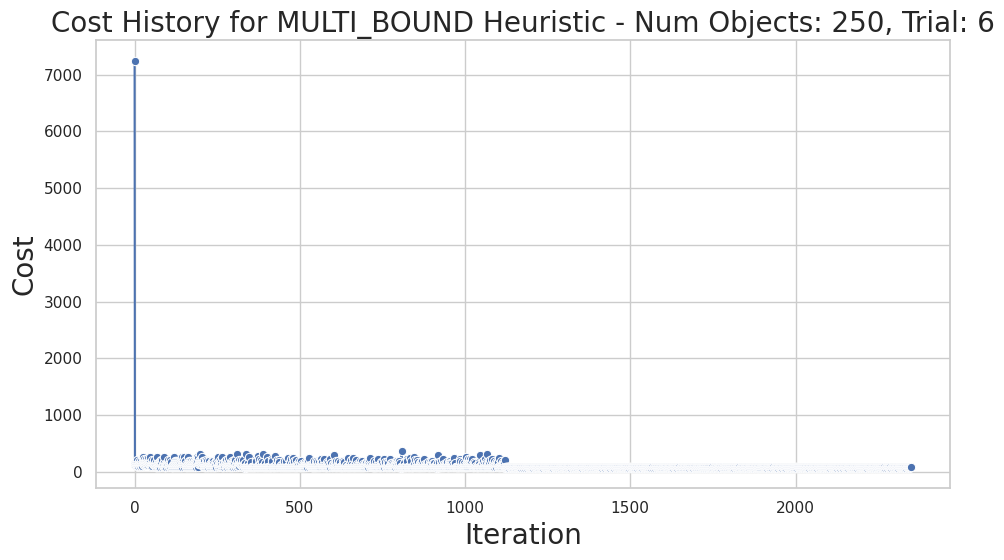

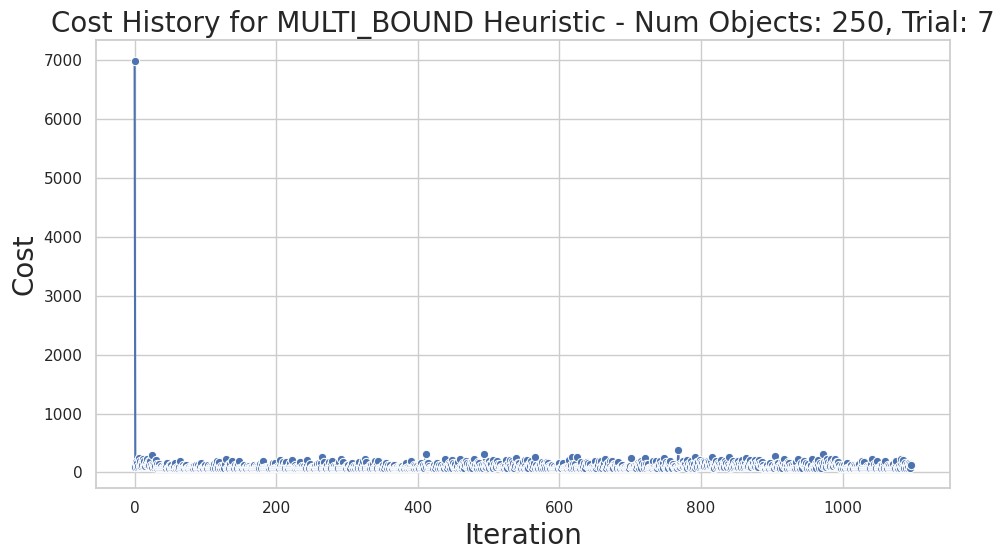

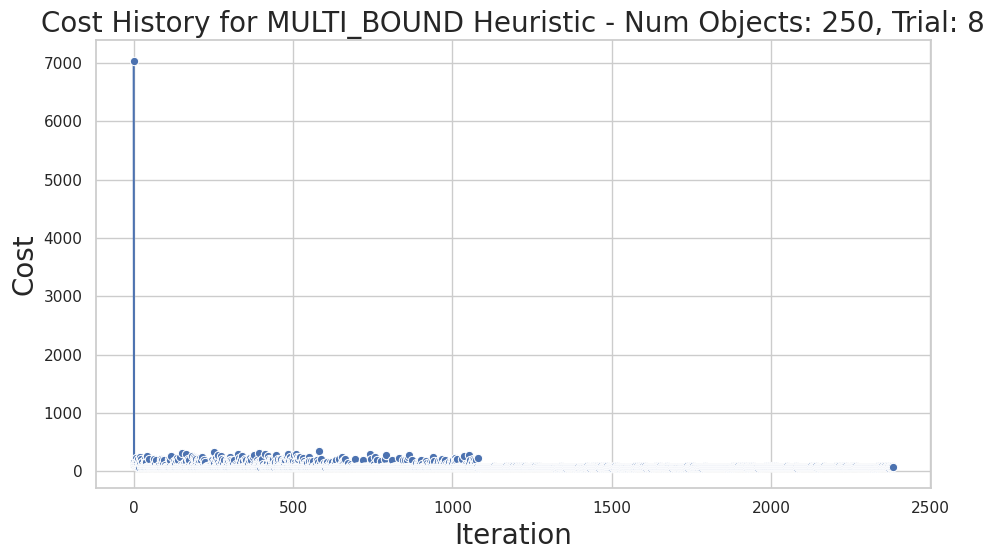

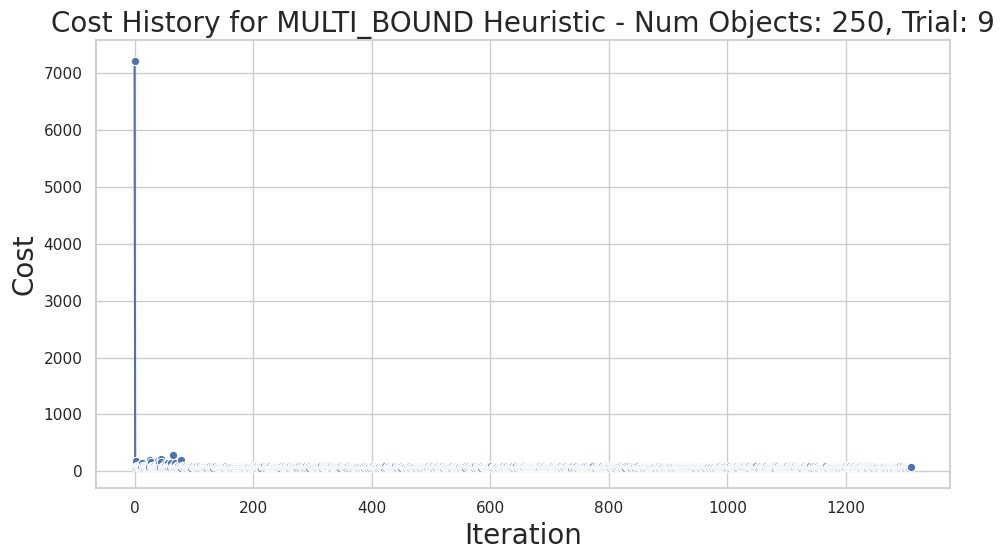

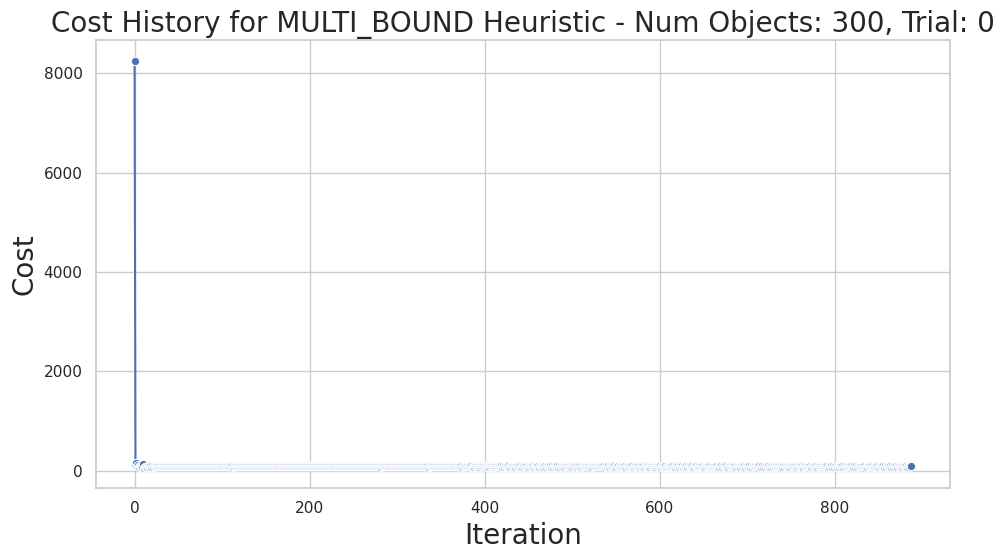

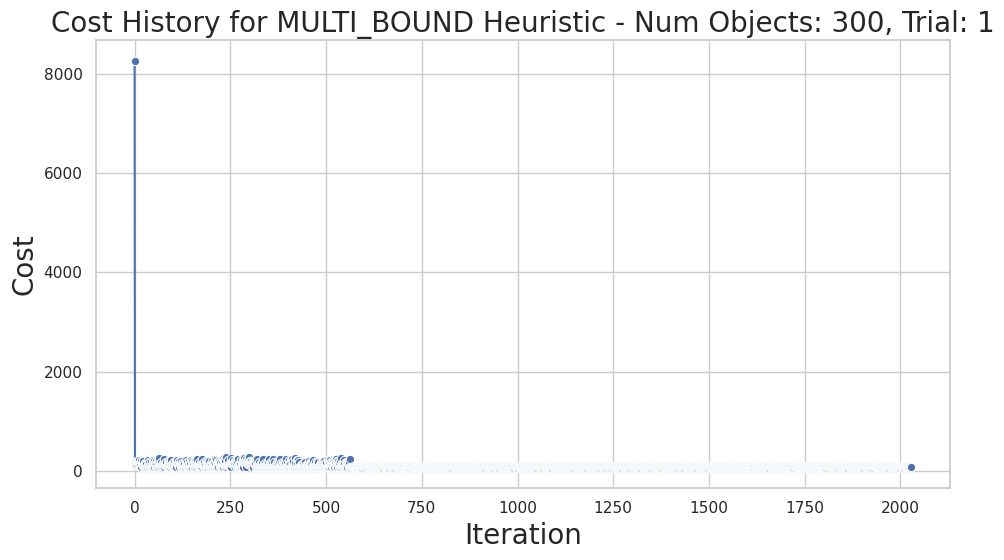

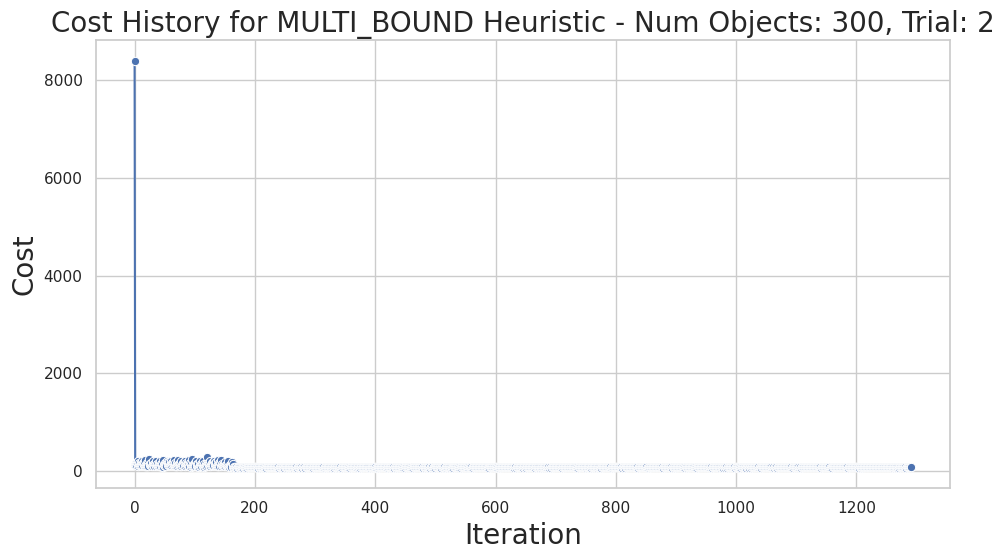

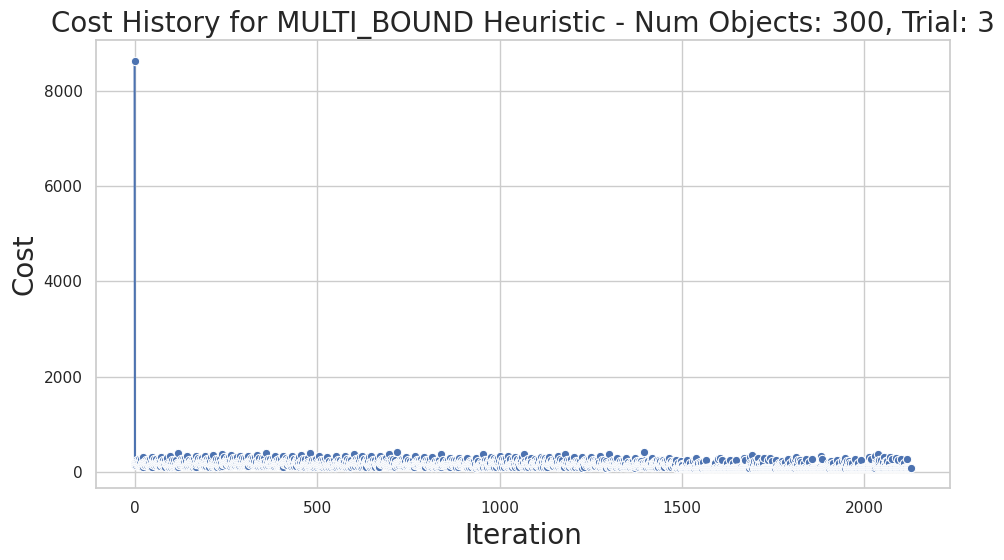

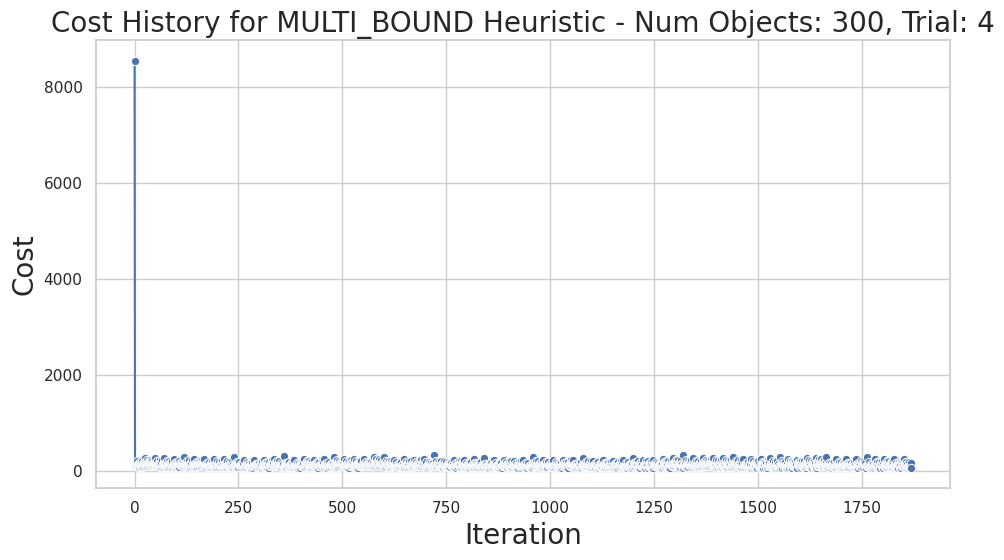

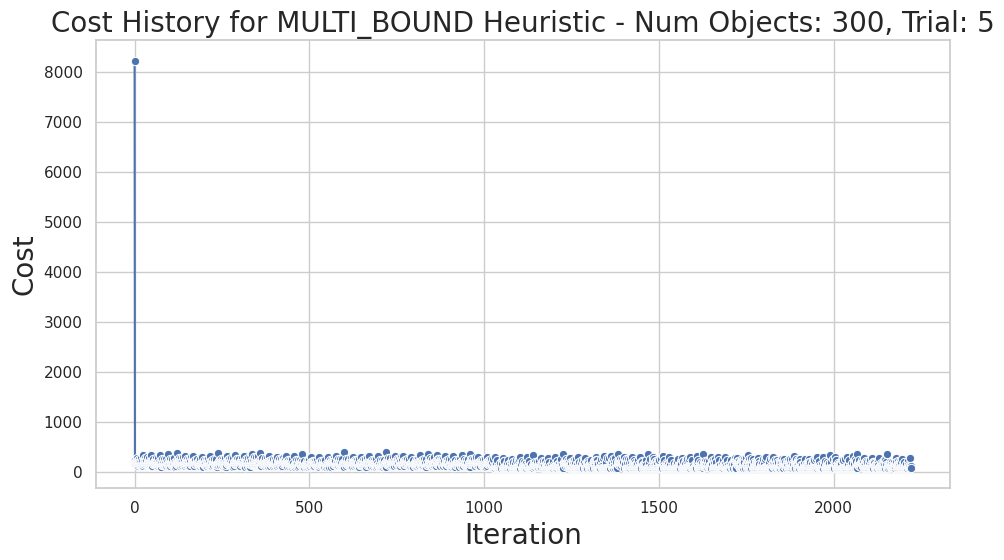

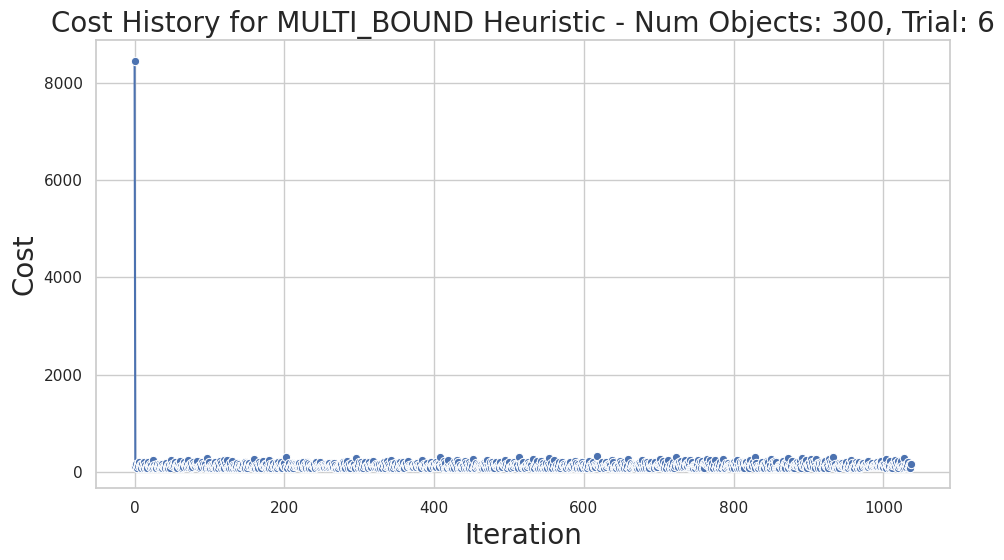

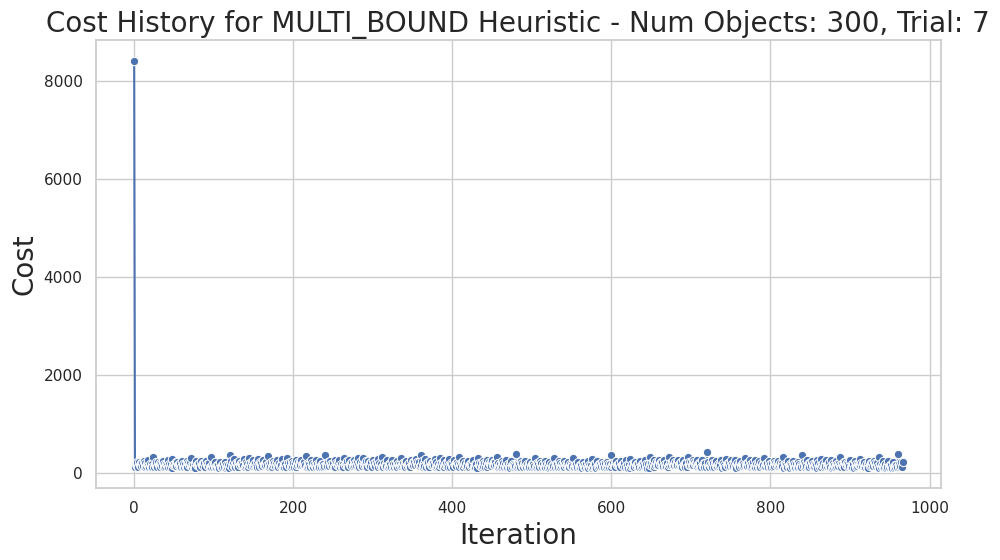

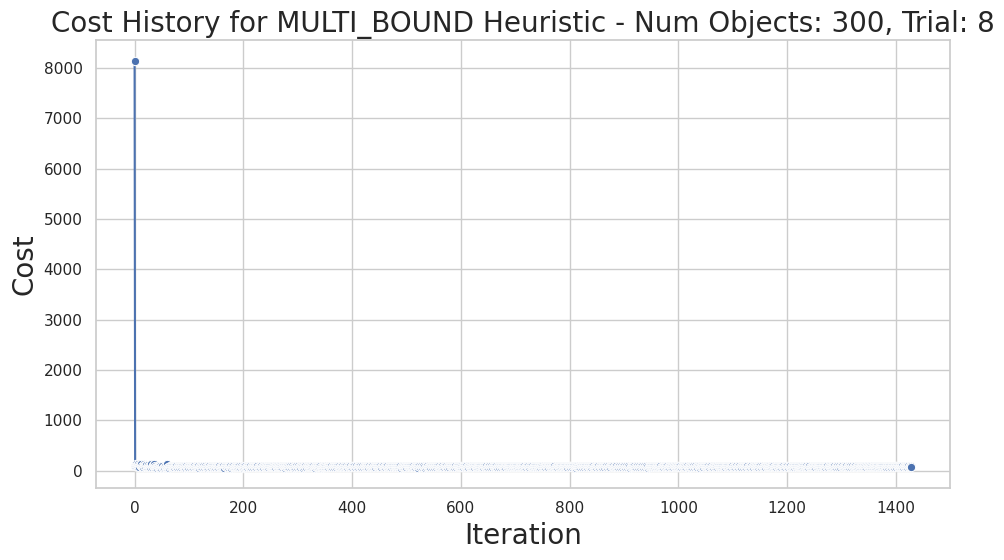

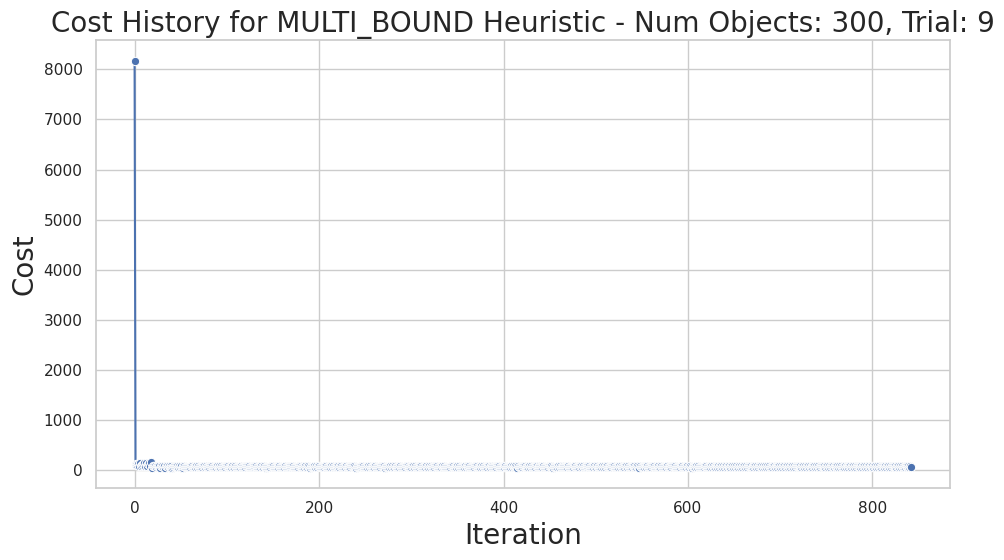

In [103]:
mb_cost_hist_df = pd.read_csv(f"{results_path}/mb_planner_comp_results_all_detailed.csv")
num_objects_list = mb_cost_hist_df['num_objects'].unique()
num_objects_list.sort()
trials = mb_cost_hist_df['trial_num'].unique()
trials.sort()

for num_objects in num_objects_list:
    for trial in trials:
        subset = mb_cost_hist_df[(mb_cost_hist_df['num_objects'] == num_objects) & (mb_cost_hist_df['trial_num'] == trial)]
        if subset.empty:
            continue
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=subset, x="iter", y="cost", marker='o')
        plt.xlabel("Iteration")
        plt.ylabel("Cost")
        plt.title(f"Cost History for MULTI_BOUND Heuristic - Num Objects: {num_objects}, Trial: {trial}")
        plt.tight_layout()
        plt.show()